# 电子商务仓储机器人应用分析报告
## E-commerce Warehouse Robotics Analysis

**小组成员：** ___________
**日期：** 2026/06/09
**数据来源：** International Federation of Robotics (IFR), McKinsey, LogisticsIQ

---

## 报告结构
1. 全球仓储机器人市场规模与预测
2. 机器人类型分布与市场占比
3. 各地区电商机器人采用率对比
4. 头部企业市场份额分析
5. 机器人投资回报率(ROI)分析
6. 应用场景分布与趋势


In [1]:
# ============================================================
# 0. 环境准备
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
import squarify
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')

# 注: 先设置 seaborn 样式，再配置中文字体 —— sns.set_style() 会重置 font.sans-serif
sns.set_style('whitegrid')
sns.set_context('notebook')

# 中文字体 — 显式注册字体文件路径 + 重建缓存
# 关键: 必须在 sns.set_style() 之后设置，否则会被 Arial 覆盖导致中文白框
_font_candidates = [
    ('SimHei', 'C:/Windows/Fonts/simhei.ttf'),
    ('Microsoft YaHei', 'C:/Windows/Fonts/msyh.ttc'),
    ('Noto Sans SC', 'C:/Windows/Fonts/NotoSansSC-VF.ttf'),
]
_added_fonts = []
for _name, _path in _font_candidates:
    if pathlib.Path(_path).exists():
        try:
            fm.fontManager.addfont(_path)
            _added_fonts.append(_name)
        except Exception:
            pass
# 重建字体管理器缓存
fm._load_fontmanager(try_read_cache=False)
# 在 seaborn 之后设置字体，确保不被覆盖
_font_list = _added_fonts + ['Microsoft YaHei', 'SimHei', 'Noto Sans SC',
                               'WenQuanYi Micro Hei', 'PingFang SC', 'Heiti SC',
                               'Arial Unicode MS', 'sans-serif']
plt.rcParams['font.sans-serif'] = _font_list
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
print(f'注册字体: {_added_fonts}')

os.makedirs('outputs/figures', exist_ok=True)
print('环境准备完成')

注册字体: ['SimHei', 'Microsoft YaHei', 'Noto Sans SC']
环境准备完成


## 1. 全球仓储机器人市场规模数据

In [2]:
# ============================================================
# 1.1 全球仓储机器人市场规模 (2020-2027)
# 数据来源: LogisticsIQ Warehouse Automation Market Report 2025
# ============================================================
years = list(range(2020, 2028))
market_size = [4.2, 5.5, 7.1, 9.0, 11.8, 14.7, 18.2, 22.5]  # 十亿美元
growth_rate = [None, 31.0, 29.1, 26.8, 31.1, 24.6, 23.8, 23.6]  # %

df_market = pd.DataFrame({
    '年份': years,
    '市场规模(十亿美元)': market_size,
    '年增长率(%)': growth_rate
})
df_market


,年份,市场规模(十亿美元),年增长率(%)
0,2020,4.2,NaN
1,2021,5.5,31.0
2,2022,7.1,29.1
3,2023,9.0,26.8
4,2024,11.8,31.1
5,2025,14.7,24.6
6,2026,18.2,23.8
7,2027,22.5,23.6


## 2. 市场趋势组合图 (柱状图+折线图)

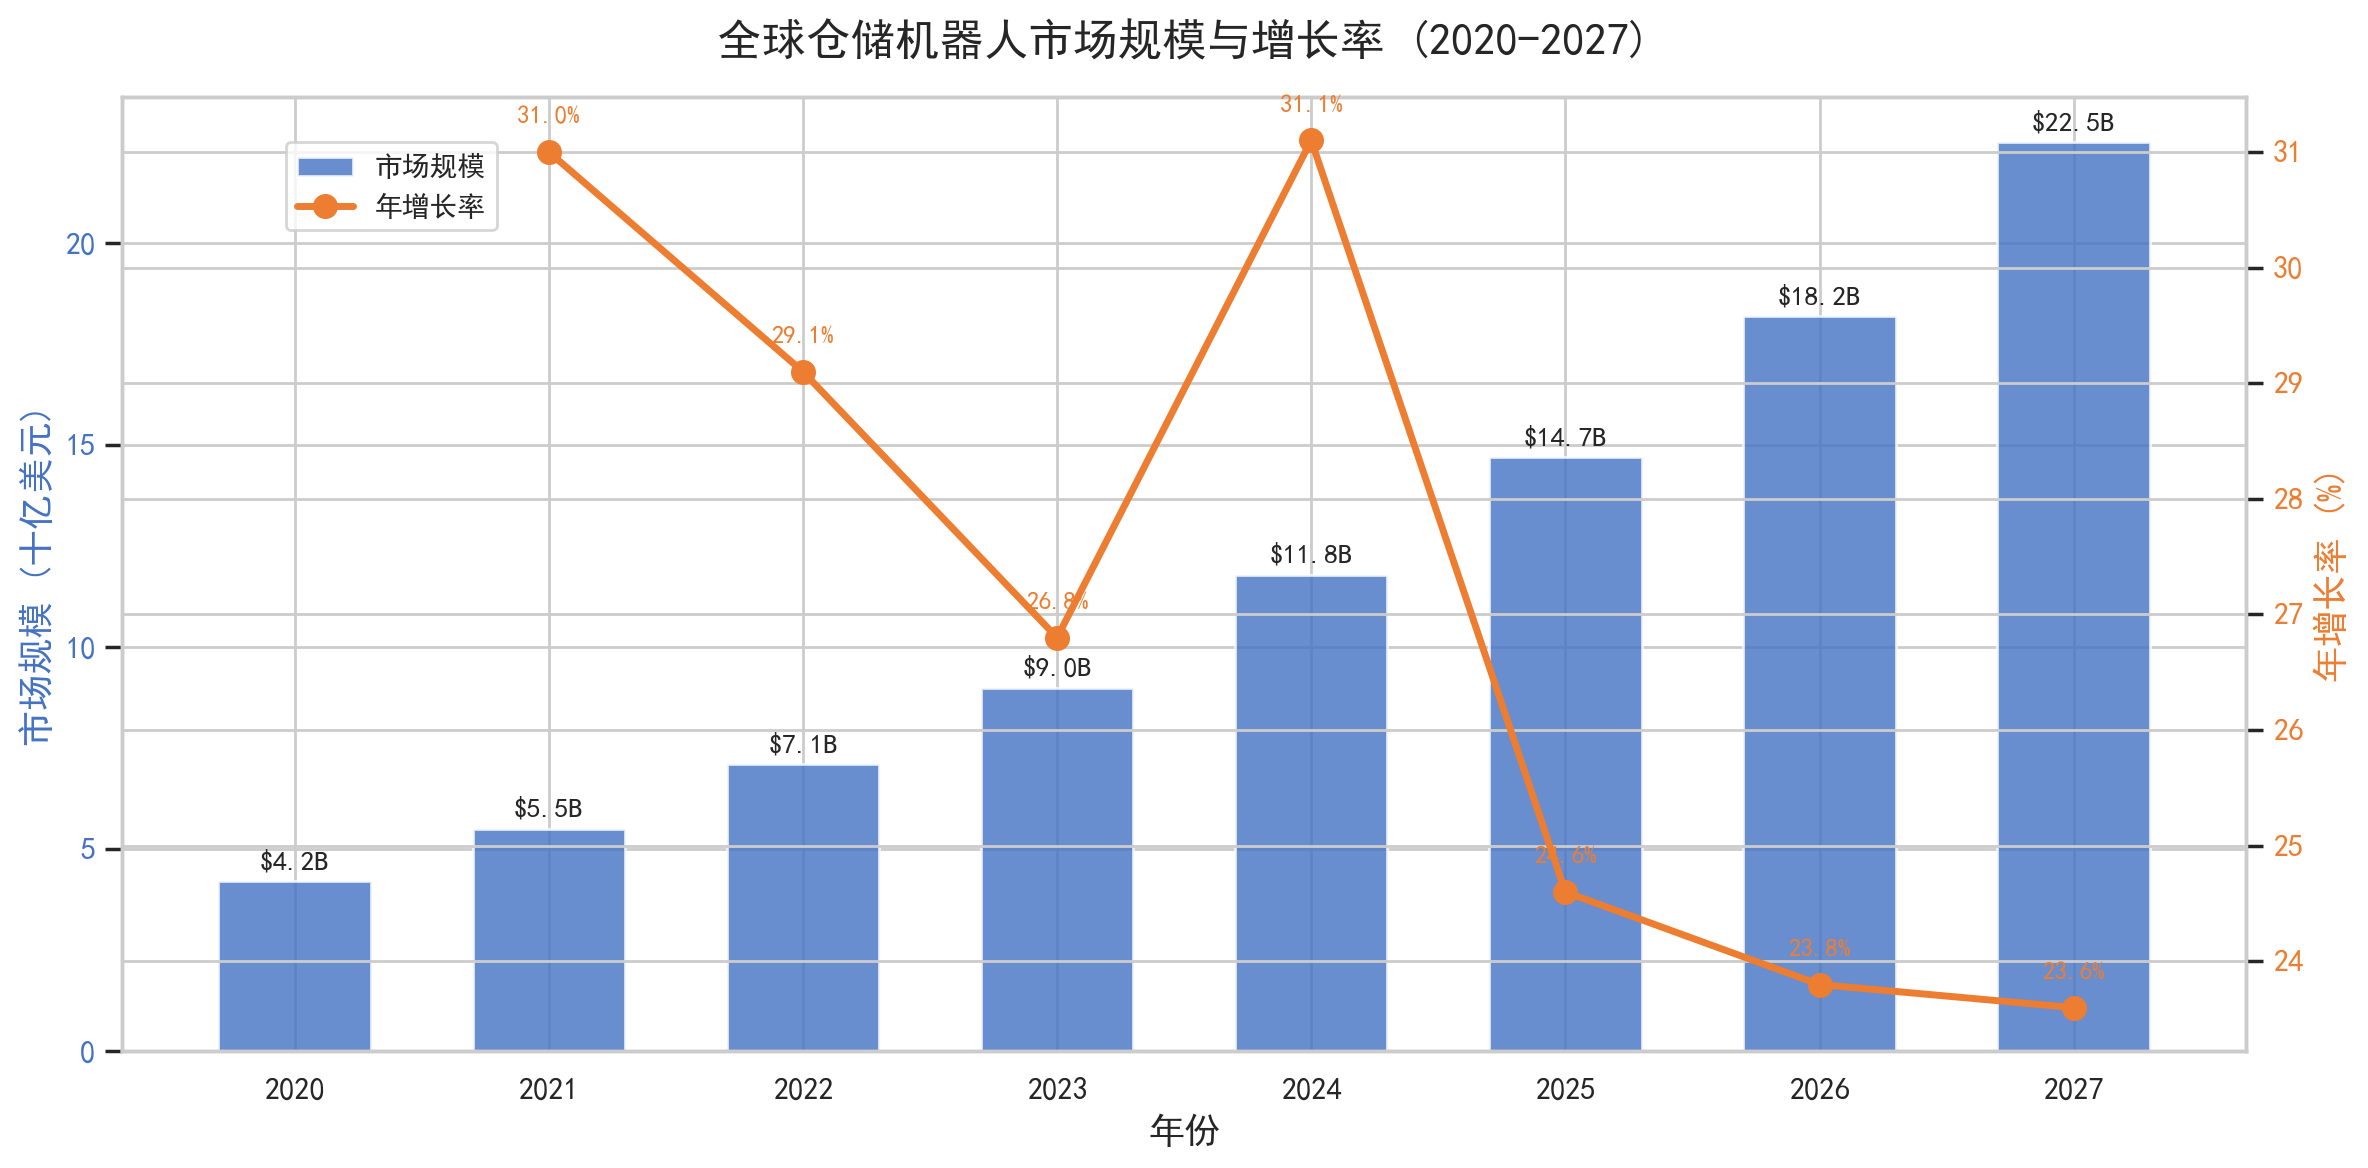

图1已保存: 01_market_size_trend.png


In [3]:
# ============================================================
# 图1: 全球仓储机器人市场规模与增长率 (双Y轴)
# 技术参考: Matplotlib入门 - 双轴图
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=200)

# 柱状图 - 市场规模
bars = ax1.bar(df_market['年份'], df_market['市场规模(十亿美元)'],
               color='#4472C4', alpha=0.8, width=0.6, label='市场规模')
ax1.set_xlabel('年份', fontsize=13)
ax1.set_ylabel('市场规模 (十亿美元)', fontsize=13, color='#4472C4')
ax1.tick_params(axis='y', labelcolor='#4472C4')

for bar, val in zip(bars, df_market['市场规模(十亿美元)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${val}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 折线图 - 增长率
ax2 = ax1.twinx()
ax2.plot(df_market['年份'][1:], df_market['年增长率(%)'][1:],
         'o-', color='#ED7D31', linewidth=2.5, markersize=8, label='年增长率')
ax2.set_ylabel('年增长率 (%)', fontsize=13, color='#ED7D31')
ax2.tick_params(axis='y', labelcolor='#ED7D31')

for x, y in zip(df_market['年份'][1:], df_market['年增长率(%)'][1:]):
    ax2.annotate(f'{y}%', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9, color='#ED7D31')

ax1.set_title('全球仓储机器人市场规模与增长率 (2020-2027)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(years)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88), fontsize=10)
fig.tight_layout()
plt.savefig('outputs/figures/01_market_size_trend.png', dpi=200, bbox_inches='tight')
plt.show()
print("图1已保存: 01_market_size_trend.png")


## 3. 机器人类型数据

In [4]:
# ============================================================
# 1.2 仓储机器人类型
# ============================================================
robot_types = [
    'AMR(自主移动)', 'AGV(自动导引)', '机械臂', '无人机',
    '分拣机器人', '协作机器人', '其他'
]
robot_market_share = [32.5, 24.0, 18.5, 8.0, 10.5, 4.5, 2.0]
robot_growth = [35.2, 18.6, 22.1, 42.5, 28.0, 45.0, 15.0]

df_robots = pd.DataFrame({
    '机器人类型': robot_types,
    '市场份额(%)': robot_market_share,
    '年增长率(%)': robot_growth
})
df_robots


,机器人类型,市场份额(%),年增长率(%)
0,AMR(自主移动),32.5,35.2
1,AGV(自动导引),24.0,18.6
2,机械臂,18.5,22.1
3,无人机,8.0,42.5
4,分拣机器人,10.5,28.0
5,协作机器人,4.5,45.0
6,其他,2.0,15.0


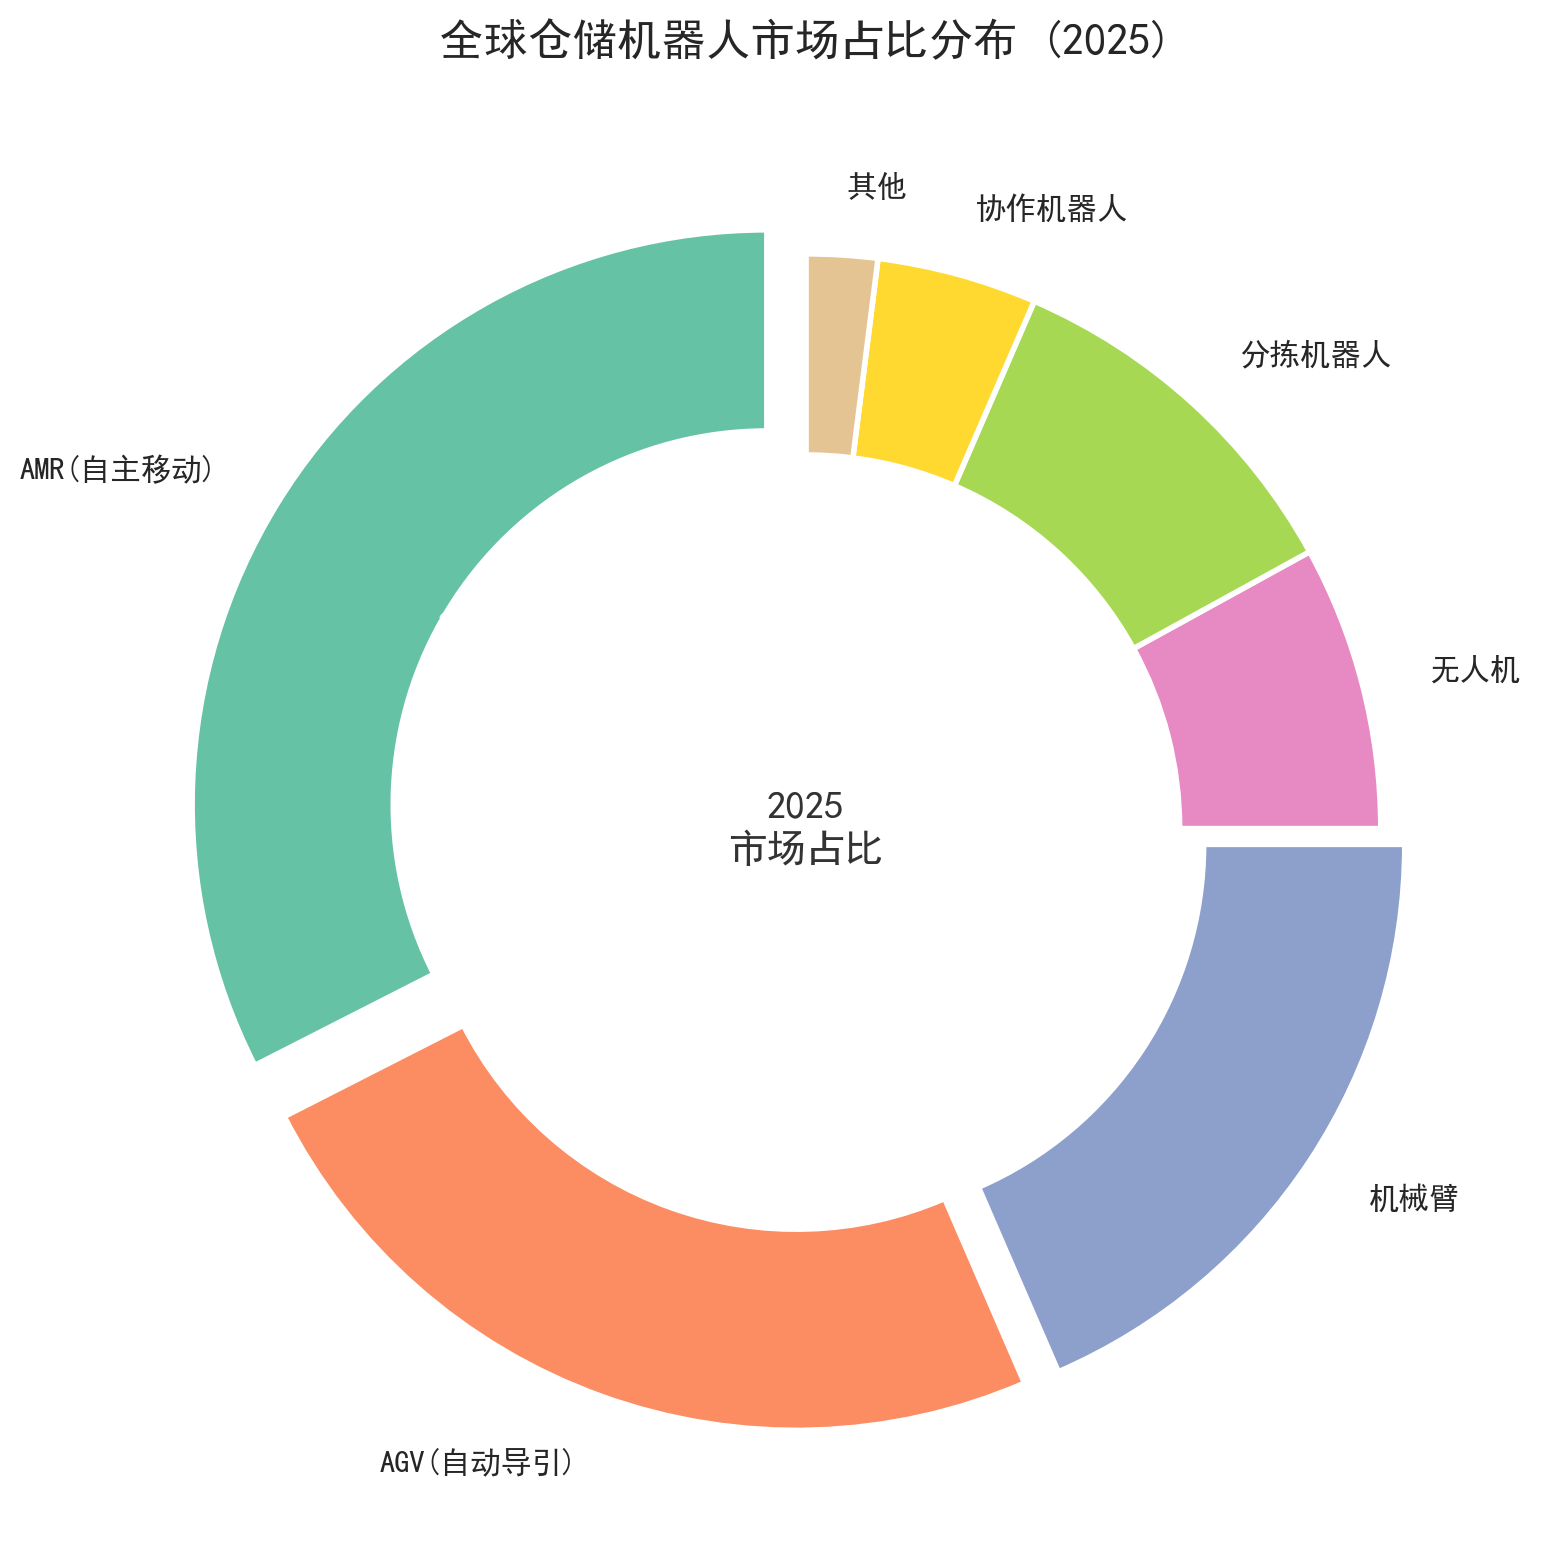

图2已保存: 02_robot_market_pie.png


In [5]:
# ============================================================
# 图2: 仓储机器人市场份额环形图 (Donut Chart)
# 技术参考: 环形图 — plt.pie + 中心白色圆
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)

colors = sns.color_palette('Set2', len(robot_types))
explode = [0.08, 0.05, 0.05, 0, 0, 0, 0]

wedges, texts, autotexts = ax.pie(
    robot_market_share, explode=explode,
    labels=robot_types, autopct='%.1f%%',
    colors=colors, startangle=90,
    pctdistance=0.6, labeldistance=1.12,
    wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
for text in texts:
    text.set_fontsize(11)

# 中心文字
ax.text(0, 0, '2025\n市场占比', ha='center', va='center', fontsize=14, fontweight='bold', color='#333')

ax.set_title('全球仓储机器人市场占比分布 (2025)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/02_robot_market_pie.png', dpi=200, bbox_inches='tight')
plt.show()
print("图2已保存: 02_robot_market_pie.png")

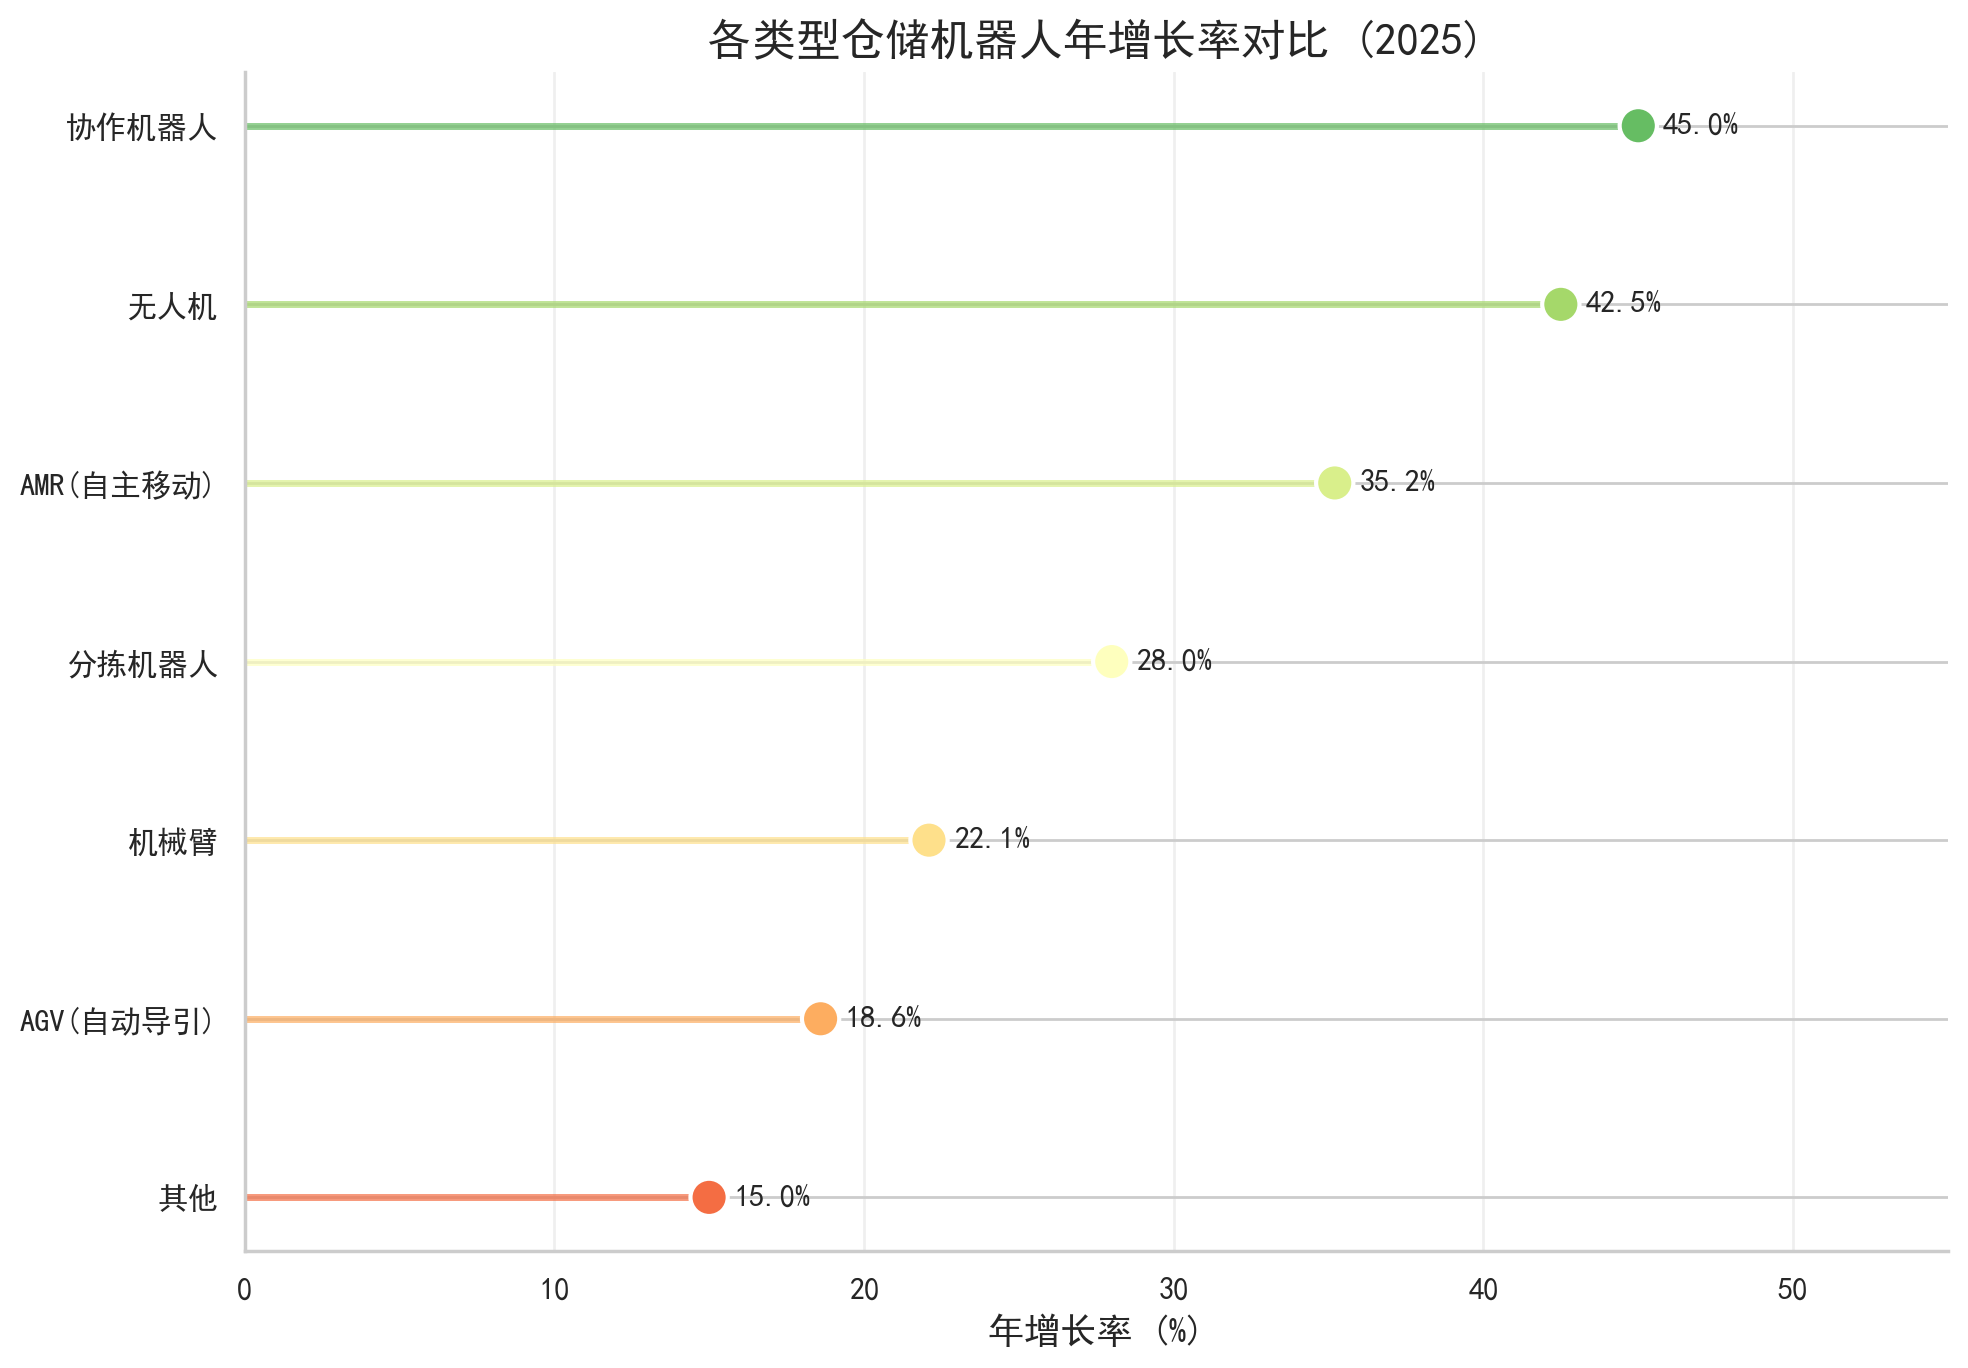

图3已保存: 03_robot_growth_barh.png


In [6]:
# ============================================================
# 图3: 各类型机器人增长率 - 克利夫兰点图 (Lollipop Chart)
# 技术参考: 克利夫兰点图 — ax.hlines + ax.scatter
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)

sorted_idx = np.argsort(robot_growth)
sorted_types = [robot_types[i] for i in sorted_idx]
sorted_growth = [robot_growth[i] for i in sorted_idx]
colors_dot = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sorted_growth)))

# 水平线 (棒棒糖的"棒")
ax.hlines(y=range(len(sorted_types)), xmin=0, xmax=sorted_growth,
          colors=colors_dot, linewidth=2.5, alpha=0.7)
# 散点 (棒棒糖的"糖")
ax.scatter(sorted_growth, range(len(sorted_types)), s=180,
           c=colors_dot, edgecolors='white', linewidth=1.5, zorder=3)

for i, val in enumerate(sorted_growth):
    ax.text(val + 0.8, i, f'{val}%', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(range(len(sorted_types)))
ax.set_yticklabels(sorted_types, fontsize=11)
ax.set_xlabel('年增长率 (%)', fontsize=13)
ax.set_title('各类型仓储机器人年增长率对比 (2025)', fontsize=16, fontweight='bold')
ax.set_xlim(0, max(sorted_growth) + 10)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/figures/03_robot_growth_barh.png', dpi=200, bbox_inches='tight')
plt.show()
print("图3已保存: 03_robot_growth_barh.png")

## 4. 各地区电商机器人采用率

In [7]:
# ============================================================
# 2. 各地区数据
# ============================================================
regions = ['中国', '美国', '德国', '日本', '韩国', '英国', '法国', '印度', '巴西', '澳大利亚']
amr_adoption = [42, 38, 25, 22, 18, 15, 12, 8, 5, 10]
agv_adoption = [35, 28, 20, 30, 25, 18, 15, 12, 8, 8]
arm_adoption = [28, 22, 30, 32, 26, 15, 18, 10, 6, 8]
sorting_adoption = [38, 32, 20, 25, 22, 12, 10, 6, 4, 7]
total_investment = [18.5, 12.8, 6.2, 5.5, 3.8, 2.1, 1.8, 1.2, 0.8, 1.5]

df_region = pd.DataFrame({
    '地区': regions,
    'AMR采用率(%)': amr_adoption,
    'AGV采用率(%)': agv_adoption,
    '机械臂采用率(%)': arm_adoption,
    '分拣机器人采用率(%)': sorting_adoption,
    '总投资额(十亿美元)': total_investment
})
df_region


,地区,AMR采用率(%),AGV采用率(%),机械臂采用率(%),分拣机器人采用率(%),总投资额(十亿美元)
0,中国,42,35,28,38,18.5
1,美国,38,28,22,32,12.8
2,德国,25,20,30,20,6.2
3,日本,22,30,32,25,5.5
4,韩国,18,25,26,22,3.8
5,英国,15,18,15,12,2.1
6,法国,12,15,18,10,1.8
7,印度,8,12,10,6,1.2
8,巴西,5,8,6,4,0.8
9,澳大利亚,10,8,8,7,1.5


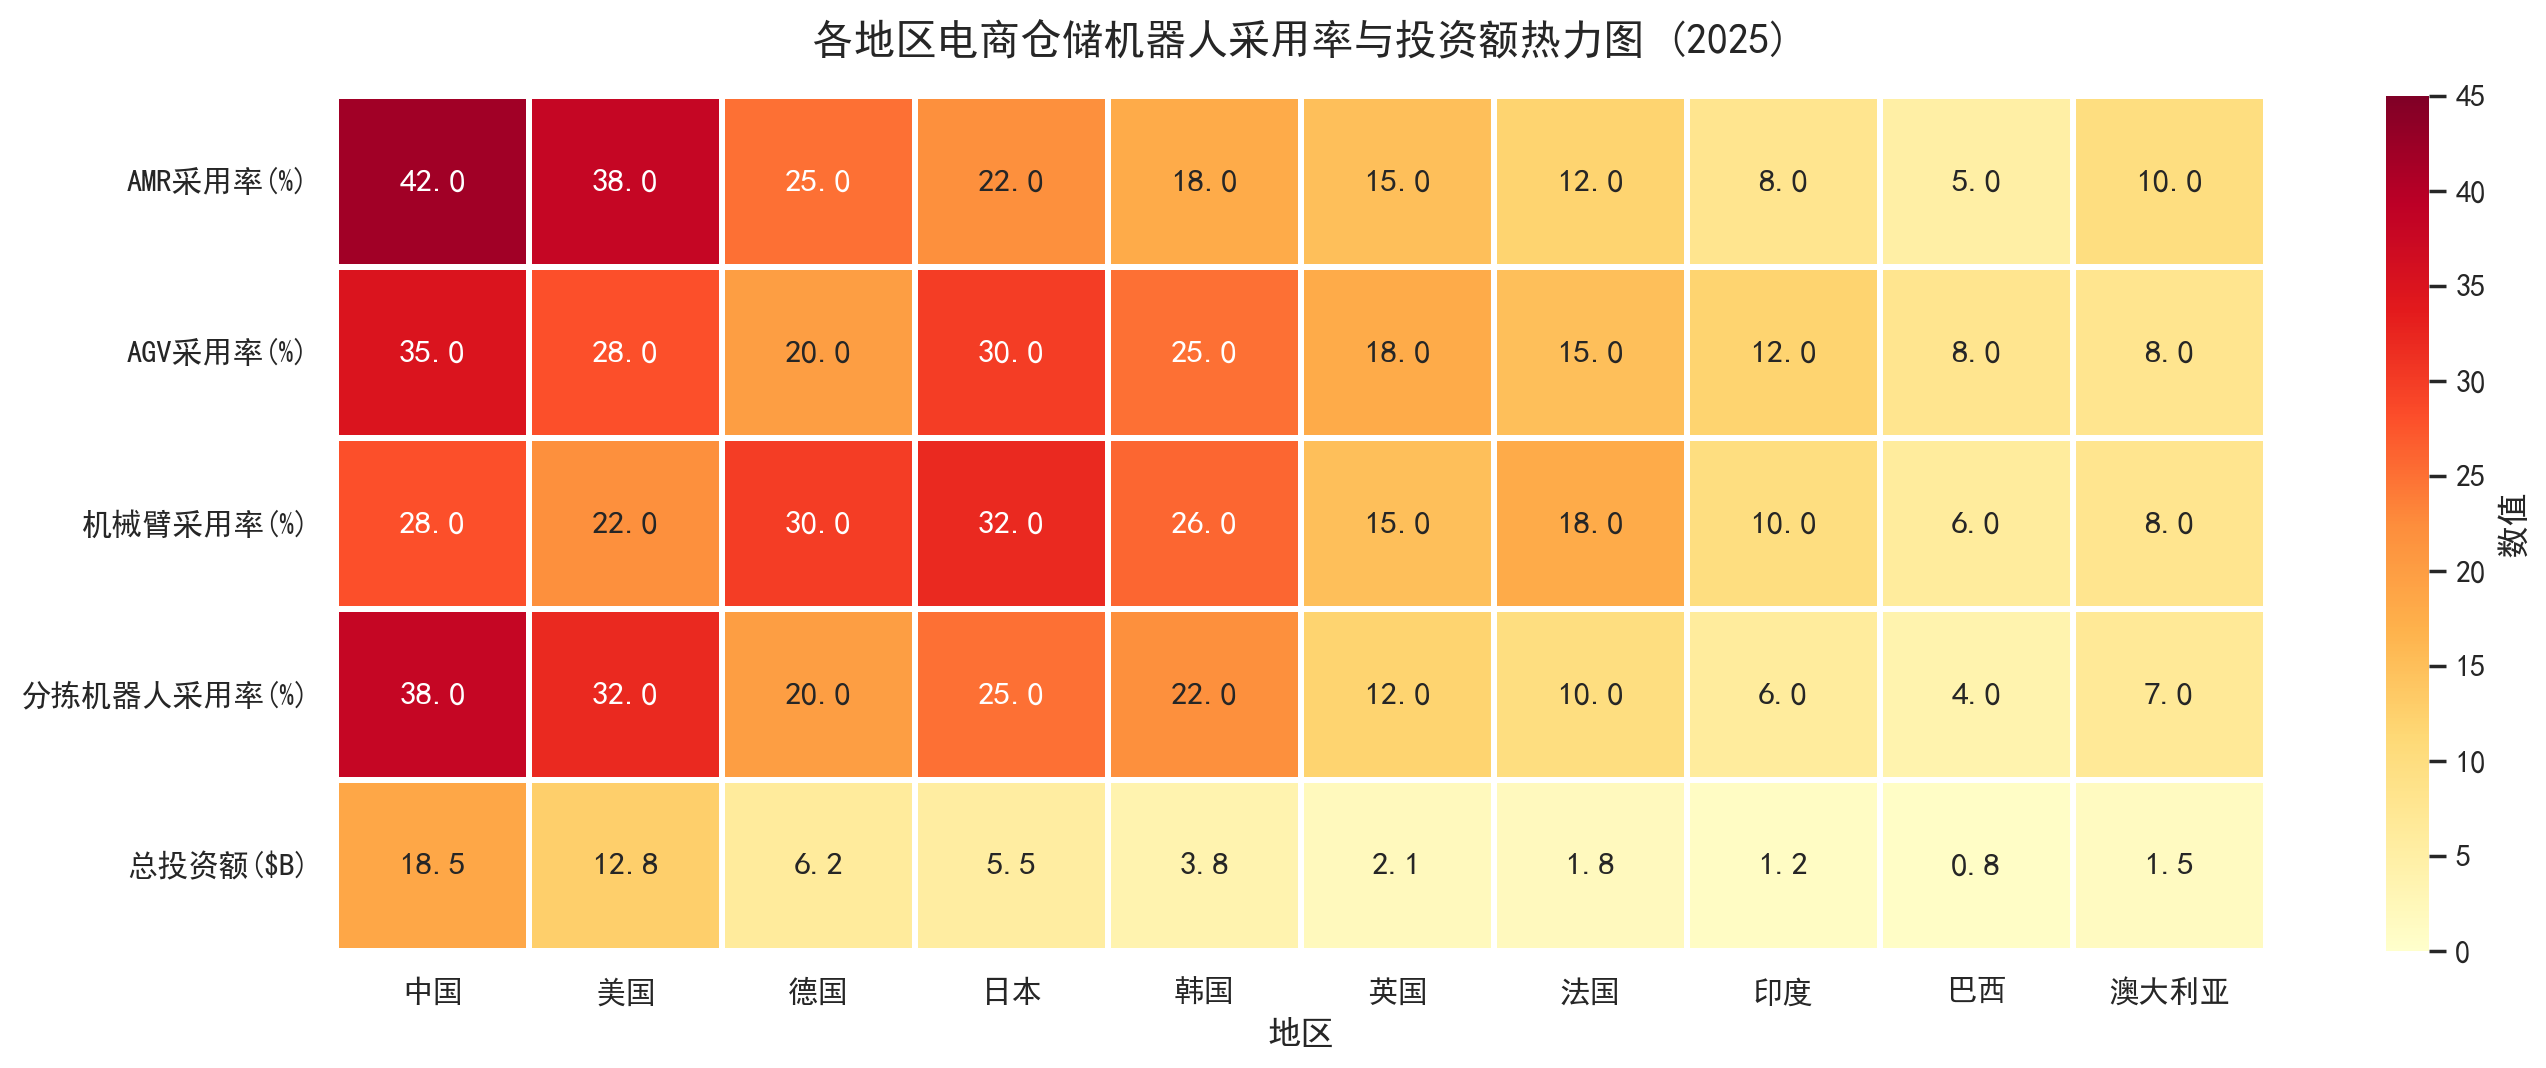

图4已保存: 04_regional_adoption_bar.png (热力图，含投资额)


In [8]:
# ============================================================
# 图4: 各地区机器人采用率 & 投资额热力图
# 技术参考: Seaborn — sns.heatmap
# 合并原图5(投资额热力图)到此图中
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5.5), dpi=200)

heatmap_data = np.array([
    amr_adoption,
    agv_adoption,
    arm_adoption,
    sorting_adoption,
    total_investment,
])
row_labels = ['AMR采用率(%)', 'AGV采用率(%)', '机械臂采用率(%)', '分拣机器人采用率(%)', '总投资额($B)']

sns.heatmap(heatmap_data, annot=True, fmt='.1f' if heatmap_data.dtype == float else 'd',
            cmap='YlOrRd', xticklabels=regions, yticklabels=row_labels,
            linewidths=1.5, linecolor='white', ax=ax,
            cbar_kws={'label': '数值', 'shrink': 1.0},
            vmin=0, vmax=45)

ax.set_title('各地区电商仓储机器人采用率与投资额热力图 (2025)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('地区', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/04_regional_adoption_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("图4已保存: 04_regional_adoption_bar.png (热力图，含投资额)")

**注：原图5(单行投资额热力图)已合并至图4热力图最后一行，删除了冗余图表。**

## 5. 头部企业市场份额分析

In [9]:
# ============================================================
# 3. 头部企业数据
# ============================================================
companies = [
    'Amazon Robotics', 'KUKA(美的)', 'ABB', 'Fanuc',
    '极智嘉(Geek+)', '海柔创新', '快仓(Quicktron)',
    'Yaskawa', 'GreyOrange', 'Other'
]
market_shares = [22.0, 15.5, 10.0, 9.5, 8.0, 7.0, 5.5, 5.0, 4.5, 13.0]
revenue = [4.9, 3.4, 2.2, 2.1, 1.8, 1.6, 1.2, 1.1, 1.0, 2.9]
employee = [35000, 15000, 10500, 8000, 2000, 1500, 1200, 5500, 1500, None]
country = ['美国', '德国(中国)', '瑞士', '日本', '中国', '中国', '中国', '日本', '印度', '-']

df_company = pd.DataFrame({
    '公司': companies,
    '市场份额(%)': market_shares,
    '营收(十亿美元)': revenue,
    '员工数': employee,
    '所属国家': country
})
df_company


,公司,市场份额(%),营收(十亿美元),员工数,所属国家
0,Amazon Robotics,22.0,4.9,35000.0,美国
1,KUKA(美的),15.5,3.4,15000.0,德国(中国)
2,ABB,10.0,2.2,10500.0,瑞士
3,Fanuc,9.5,2.1,8000.0,日本
4,极智嘉(Geek+),8.0,1.8,2000.0,中国
5,海柔创新,7.0,1.6,1500.0,中国
6,快仓(Quicktron),5.5,1.2,1200.0,中国
7,Yaskawa,5.0,1.1,5500.0,日本
8,GreyOrange,4.5,1.0,1500.0,印度
9,Other,13.0,2.9,NaN,-


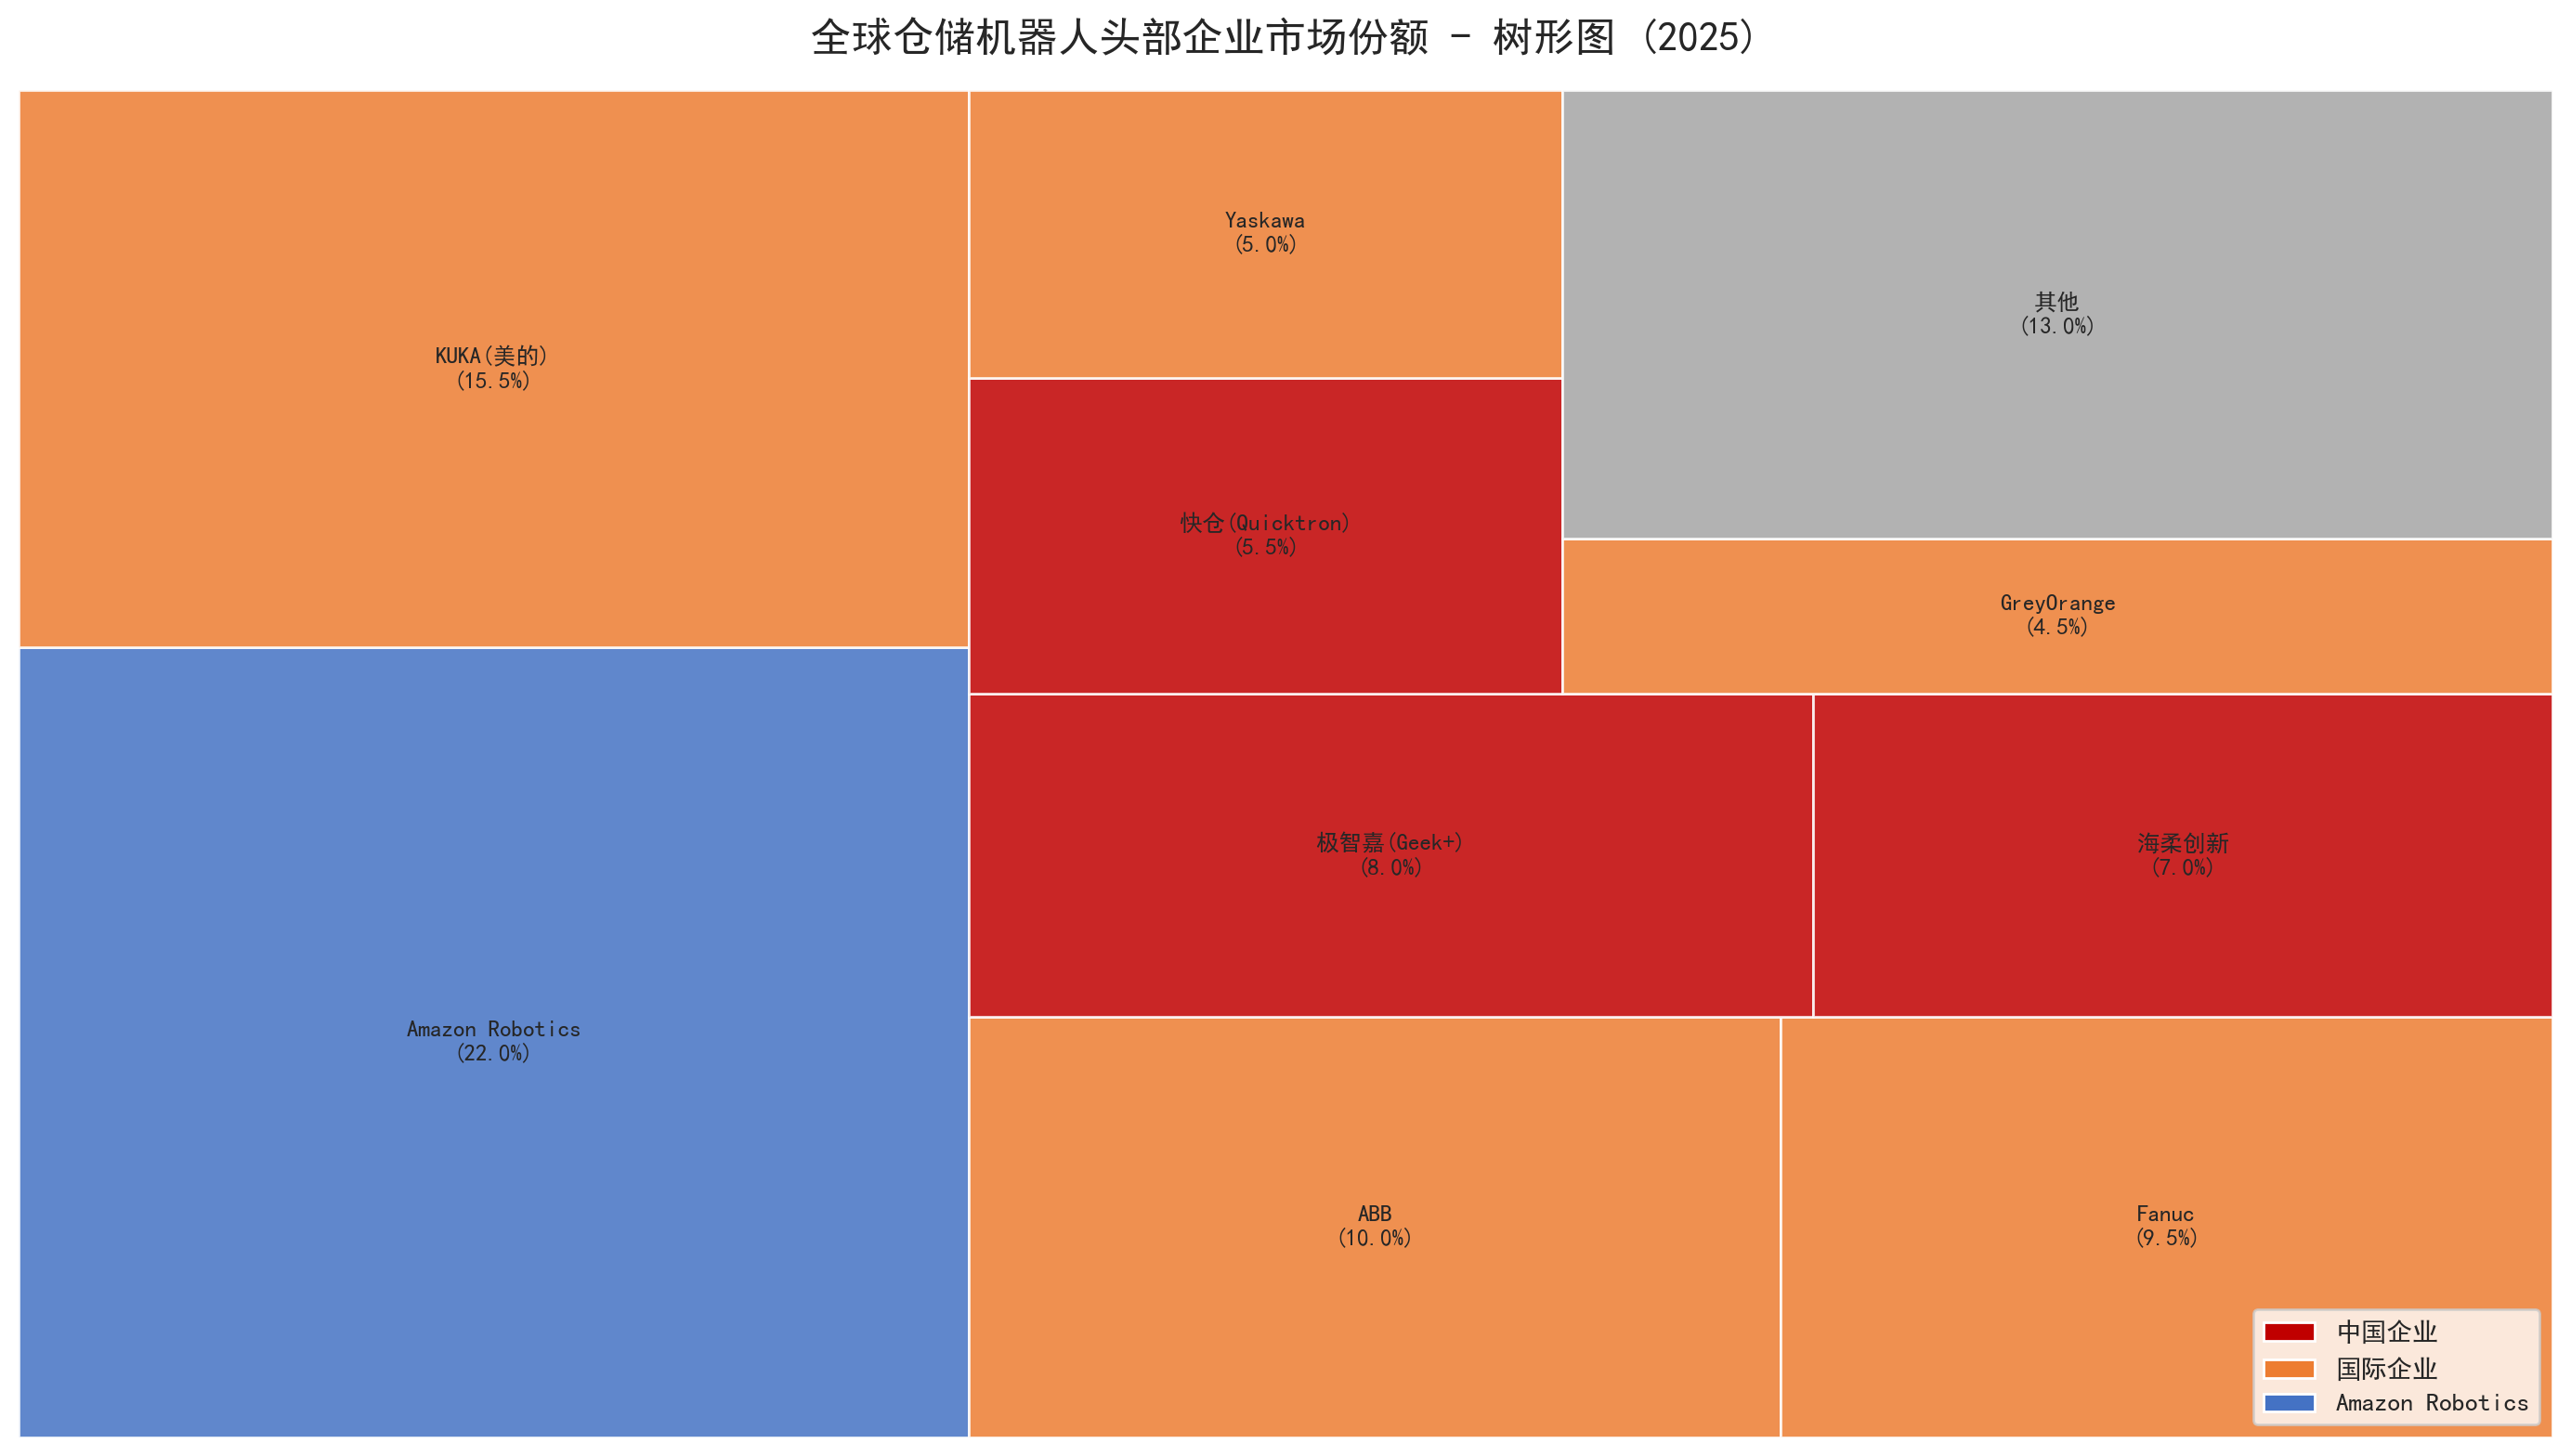

图6已保存: 06_company_treemap.png


In [10]:
# ============================================================
# 图6: 头部企业市场份额树形图
# 技术参考: Seaborn - squarify
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8), dpi=200)

company_labels = companies.copy()
company_labels[-1] = '其他'

# 中国企业标红, 国际企业标蓝
company_colors = [
    '#4472C4', '#ED7D31', '#ED7D31', '#ED7D31',
    '#C00000', '#C00000', '#C00000',
    '#ED7D31', '#ED7D31', '#A5A5A5'
]

squarify.plot(
    sizes=market_shares,
    label=[f'{n}\n({s}%)' for n, s in zip(company_labels, market_shares)],
    color=company_colors, alpha=0.85,
    text_kwargs={'fontsize': 9, 'fontweight': 'bold'}
)

ax.set_title('全球仓储机器人头部企业市场份额 - 树形图 (2025)',
             fontsize=16, fontweight='bold', pad=15)
plt.axis('off')

# 图例
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C00000', label='中国企业'),
    Patch(facecolor='#ED7D31', label='国际企业'),
    Patch(facecolor='#4472C4', label='Amazon Robotics'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/06_company_treemap.png', dpi=200, bbox_inches='tight')
plt.show()
print("图6已保存: 06_company_treemap.png")


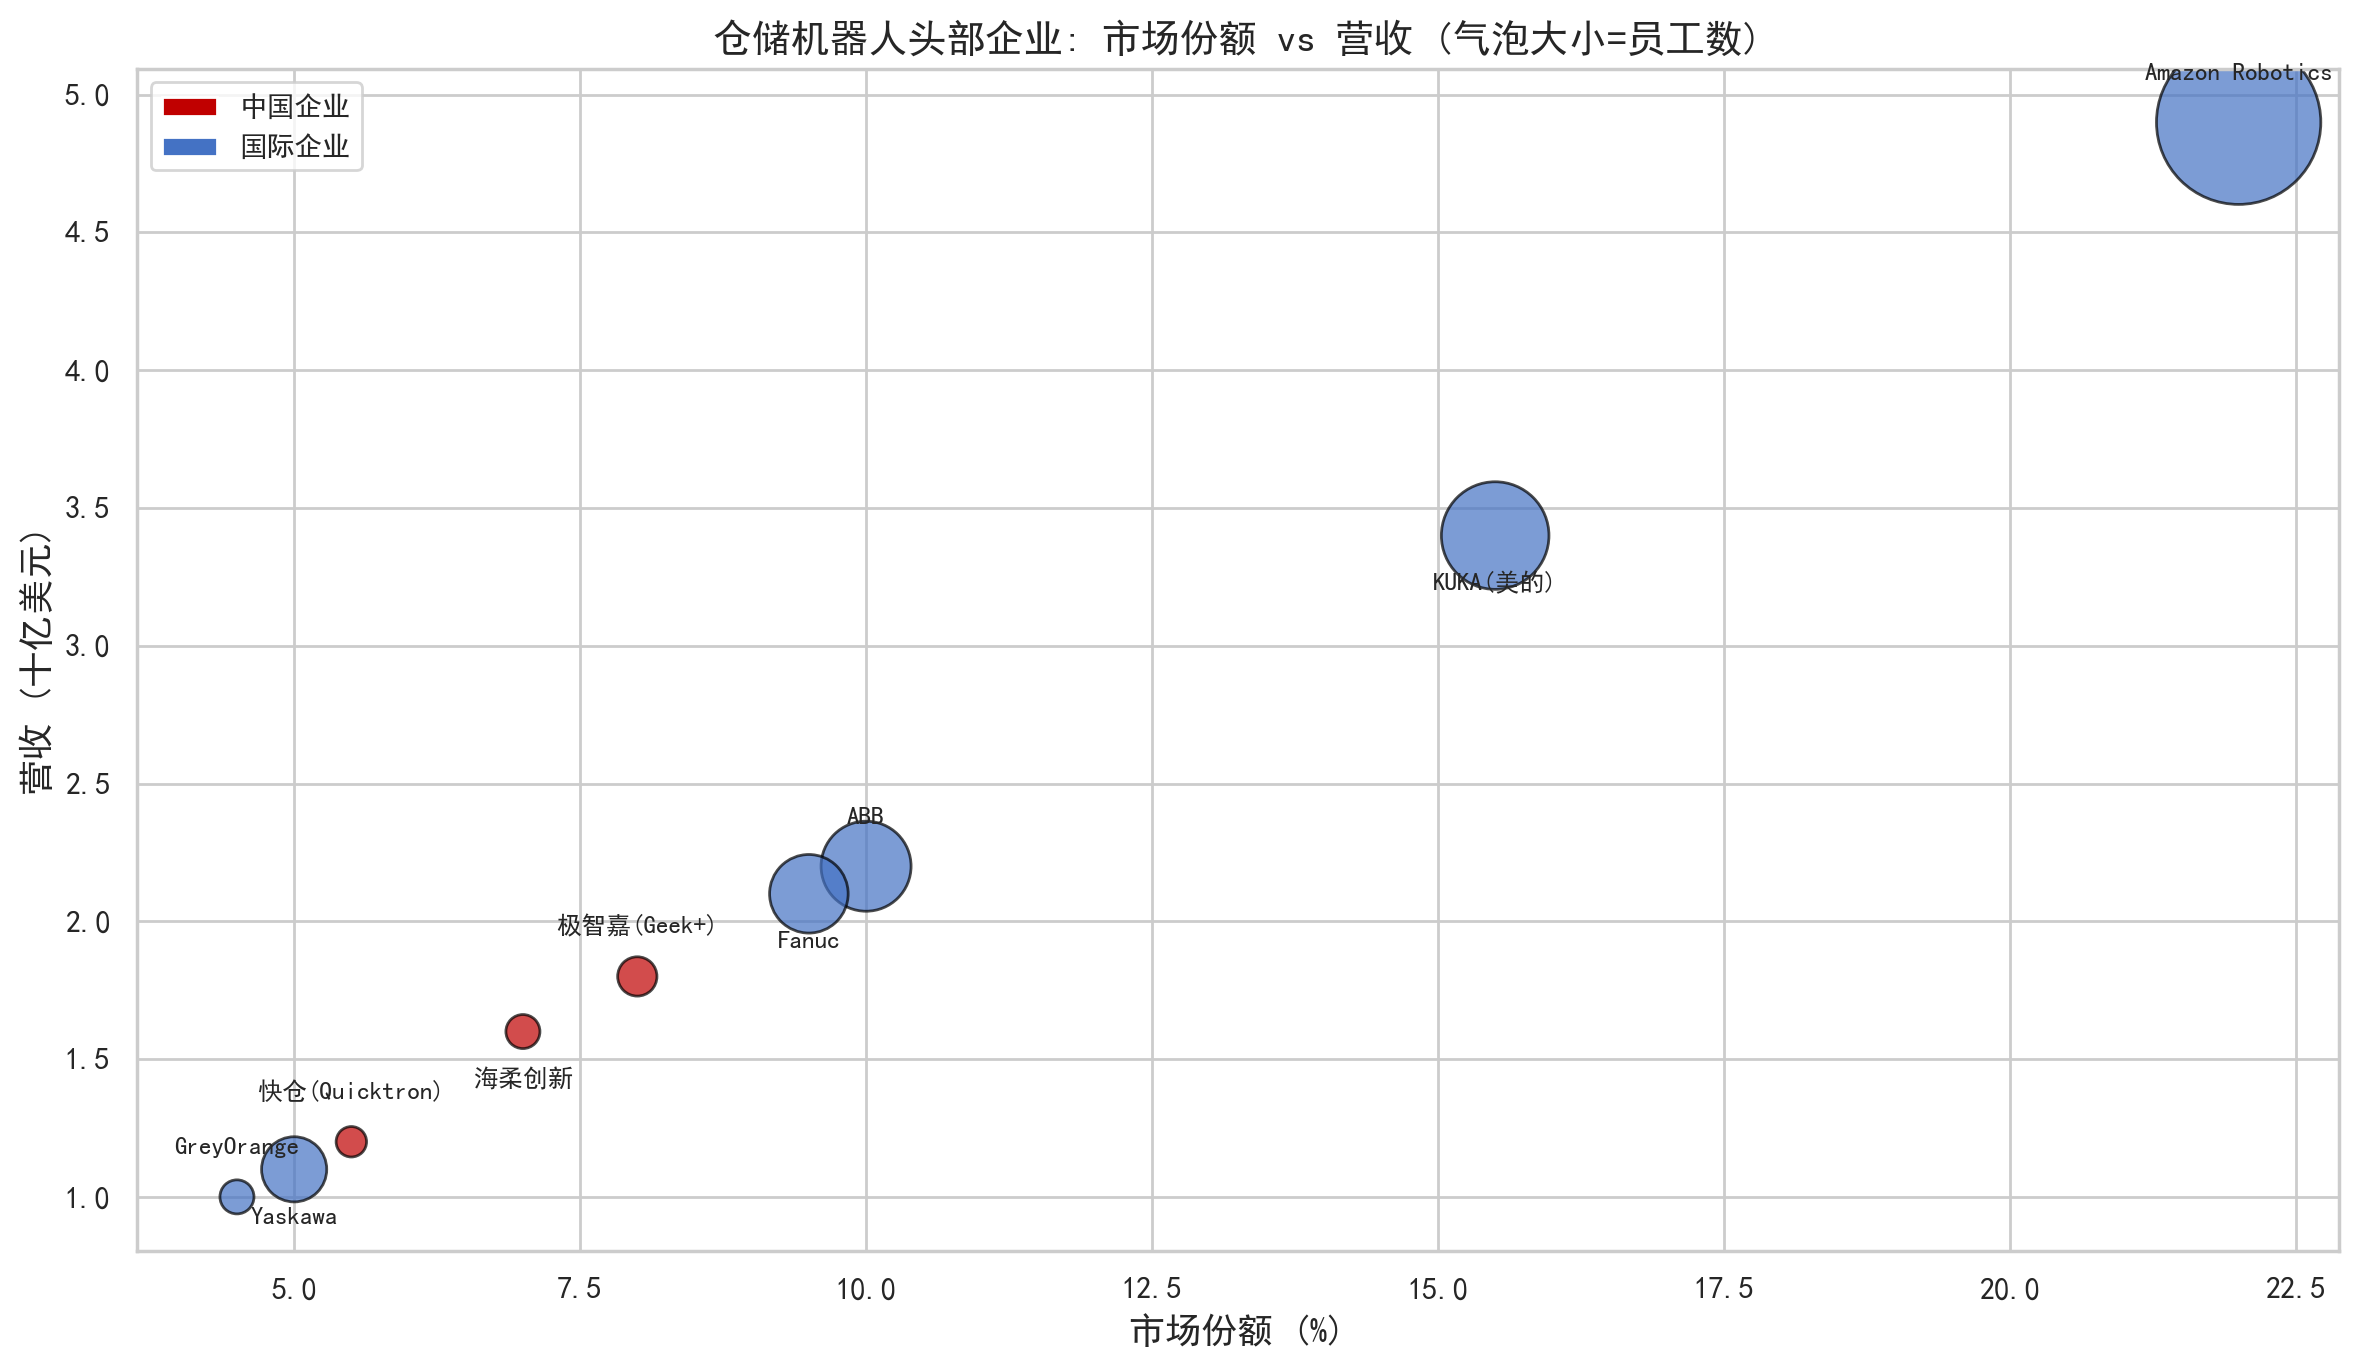

图7已保存: 07_company_bubble.png


In [11]:
# ============================================================
# 图7: 企业营收与份额 - 散点气泡图
# 技术参考: 直方图与散点图 - plt.scatter
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=200)

# 排除Other
n_plot = 9
plot_companies = companies[:n_plot]
plot_shares = market_shares[:n_plot]
plot_revenue = revenue[:n_plot]
plot_employees = employee[:n_plot]
plot_country = country[:n_plot]

colors_scatter = ['#C00000' if c == '中国' else '#4472C4' for c in plot_country]
sizes = [e/10 if e else 100 for e in plot_employees]

ax.scatter(plot_shares, plot_revenue, s=sizes, c=colors_scatter,
           alpha=0.7, edgecolors='black', linewidth=1)

for i, name in enumerate(plot_companies):
    offset = 15 if i % 2 == 0 else -20
    ax.annotate(name, (plot_shares[i], plot_revenue[i]),
                textcoords="offset points", xytext=(0, offset),
                ha='center', fontsize=9)

ax.set_xlabel('市场份额 (%)', fontsize=13)
ax.set_ylabel('营收 (十亿美元)', fontsize=13)
ax.set_title('仓储机器人头部企业: 市场份额 vs 营收 (气泡大小=员工数)',
             fontsize=14, fontweight='bold')

legend_elements = [
    Patch(facecolor='#C00000', label='中国企业'),
    Patch(facecolor='#4472C4', label='国际企业'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/07_company_bubble.png', dpi=200, bbox_inches='tight')
plt.show()
print("图7已保存: 07_company_bubble.png")


## 6. 投资回报率(ROI)分析

In [12]:
# ============================================================
# 4. ROI分析数据
# ============================================================
roi_categories = ['AMR搬运', 'AGV运输', '机械臂分拣', '无人机巡检', '分拣系统']
initial_cost = [250, 100, 180, 50, 300]       # 千美元/台
annual_saving = [85, 30, 55, 20, 100]          # 千美元/年
maintenance_cost = [8, 3, 6, 2, 10]            # 千美元/年
payback_months = [38, 44, 42, 30, 40]          # 月
labor_saved = [3.5, 2.0, 2.5, 1.0, 4.0]       # 等效人数

df_roi = pd.DataFrame({
    '机器人类型': roi_categories,
    '初始投资(千美元)': initial_cost,
    '年节省(千美元)': annual_saving,
    '年维护(千美元)': maintenance_cost,
    '回本周期(月)': payback_months,
    '节省人力(人)': labor_saved
})

# 3年净收益
df_roi['3年净收益(千美元)'] = (
    df_roi['年节省(千美元)'] * 3
    - df_roi['初始投资(千美元)']
    - df_roi['年维护(千美元)'] * 3
)
df_roi


,机器人类型,初始投资(千美元),年节省(千美元),年维护(千美元),回本周期(月),节省人力(人),3年净收益(千美元)
0,AMR搬运,250,85,8,38,3.5,-19
1,AGV运输,100,30,3,44,2.0,-19
2,机械臂分拣,180,55,6,42,2.5,-33
3,无人机巡检,50,20,2,30,1.0,4
4,分拣系统,300,100,10,40,4.0,-30


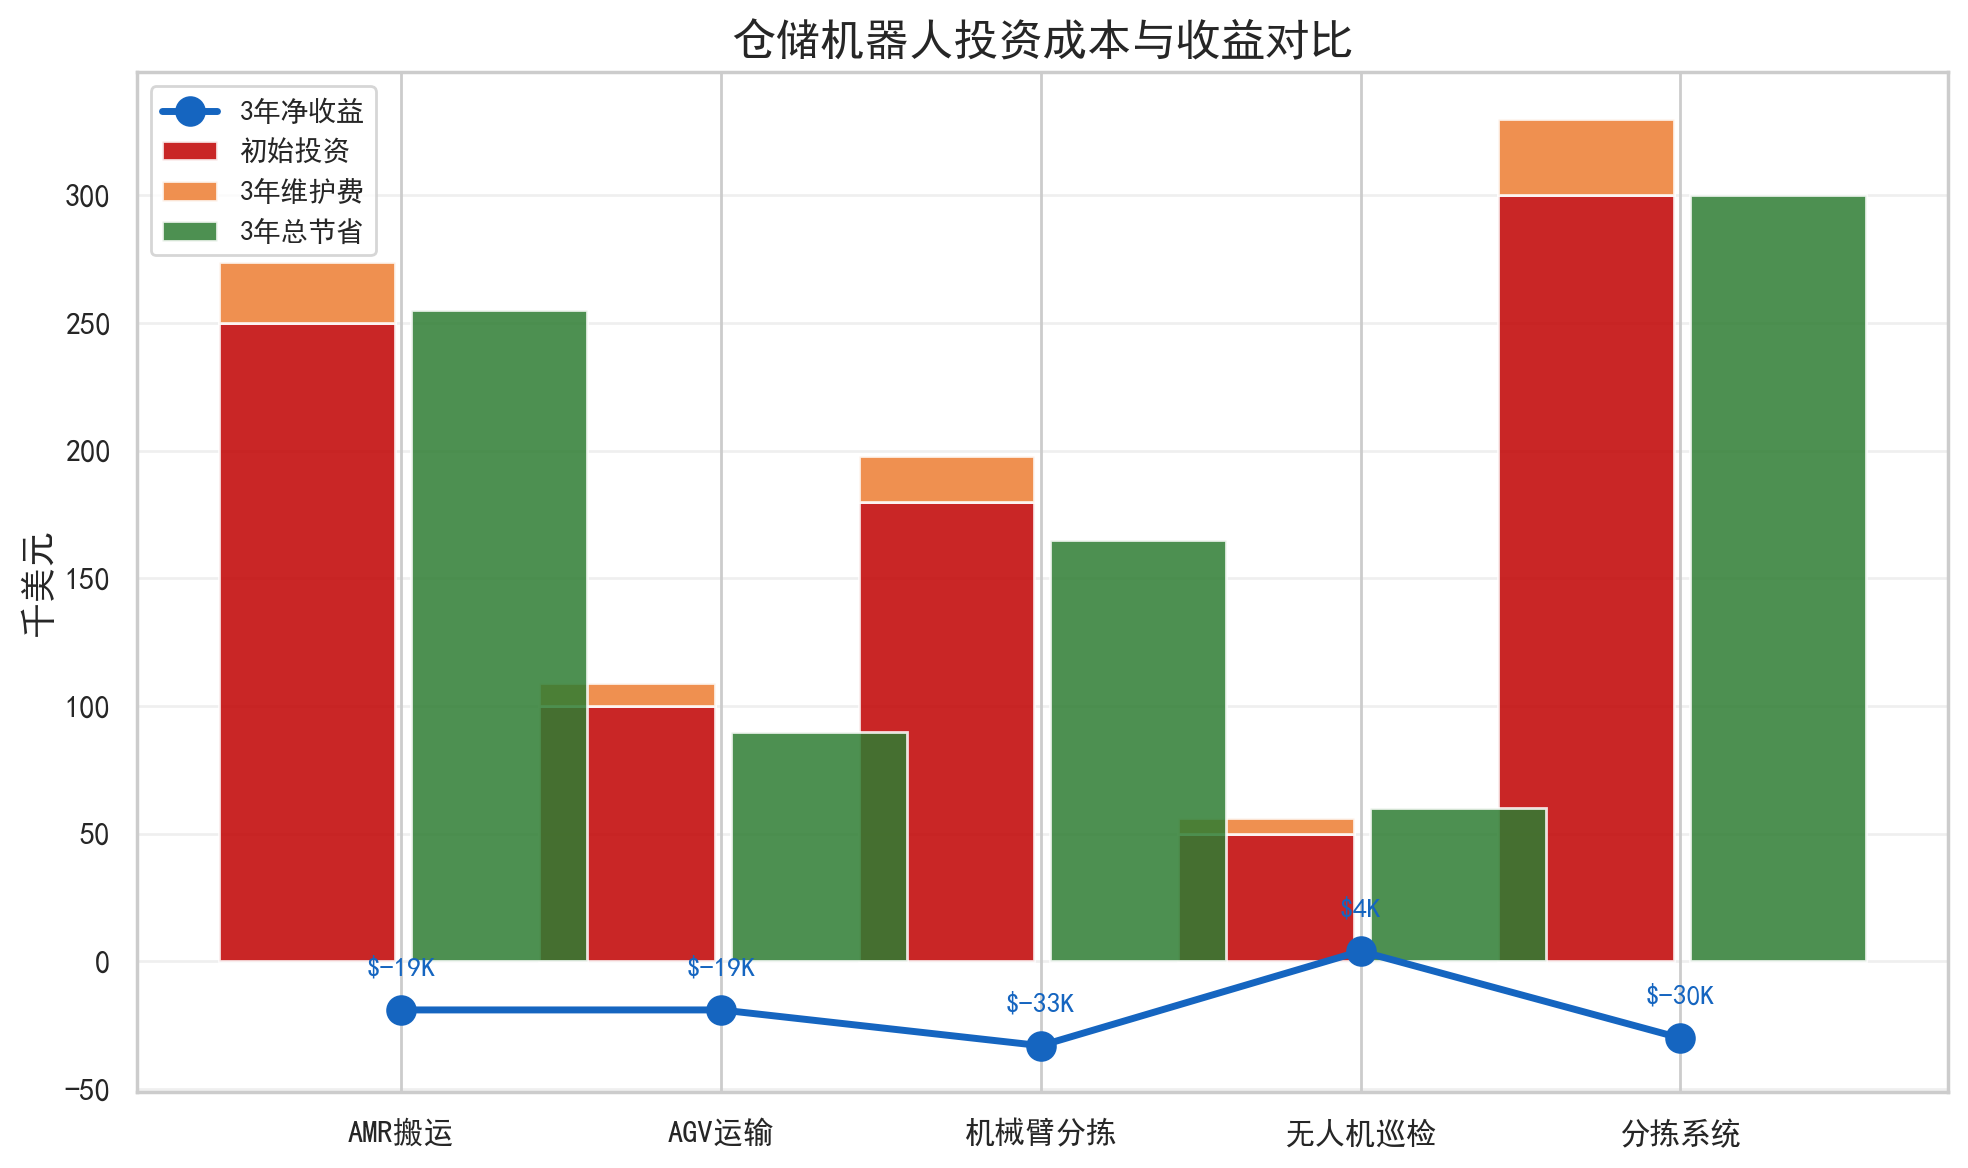

图8已保存: 08_roi_stacked_bar.png


In [13]:
# ============================================================
# 图8: ROI分析堆叠柱状图
# 技术参考: 柱状图/5-堆叠柱状图 - bottom参数
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6), dpi=200)

x = np.arange(len(roi_categories))
width = 0.55

# 初始投资
ax.bar(x, initial_cost, width, label='初始投资', color='#C00000', alpha=0.85)
# 3年维护
ax.bar(x, [m*3 for m in maintenance_cost], width,
       bottom=initial_cost, label='3年维护费', color='#ED7D31', alpha=0.85)
# 3年总节省
ax.bar(x + width + 0.05, [s*3 for s in annual_saving], width,
       label='3年总节省', color='#2E7D32', alpha=0.85)

# 净收益线
net_3y = [s*3 - c - m*3 for s, c, m in zip(annual_saving, initial_cost, maintenance_cost)]
ax.plot(x + width/2 + 0.02, net_3y, 'o-', color='#1565C0', linewidth=2.5,
        markersize=10, label='3年净收益', zorder=5)

for i, v in enumerate(net_3y):
    ax.annotate(f'${v}K', (i + width/2 + 0.02, v),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, fontweight='bold', color='#1565C0')

ax.set_xticks(x + width/2 + 0.02)
ax.set_xticklabels(roi_categories)
ax.set_ylabel('千美元', fontsize=13)
ax.set_title('仓储机器人投资成本与收益对比', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/08_roi_stacked_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("图8已保存: 08_roi_stacked_bar.png")


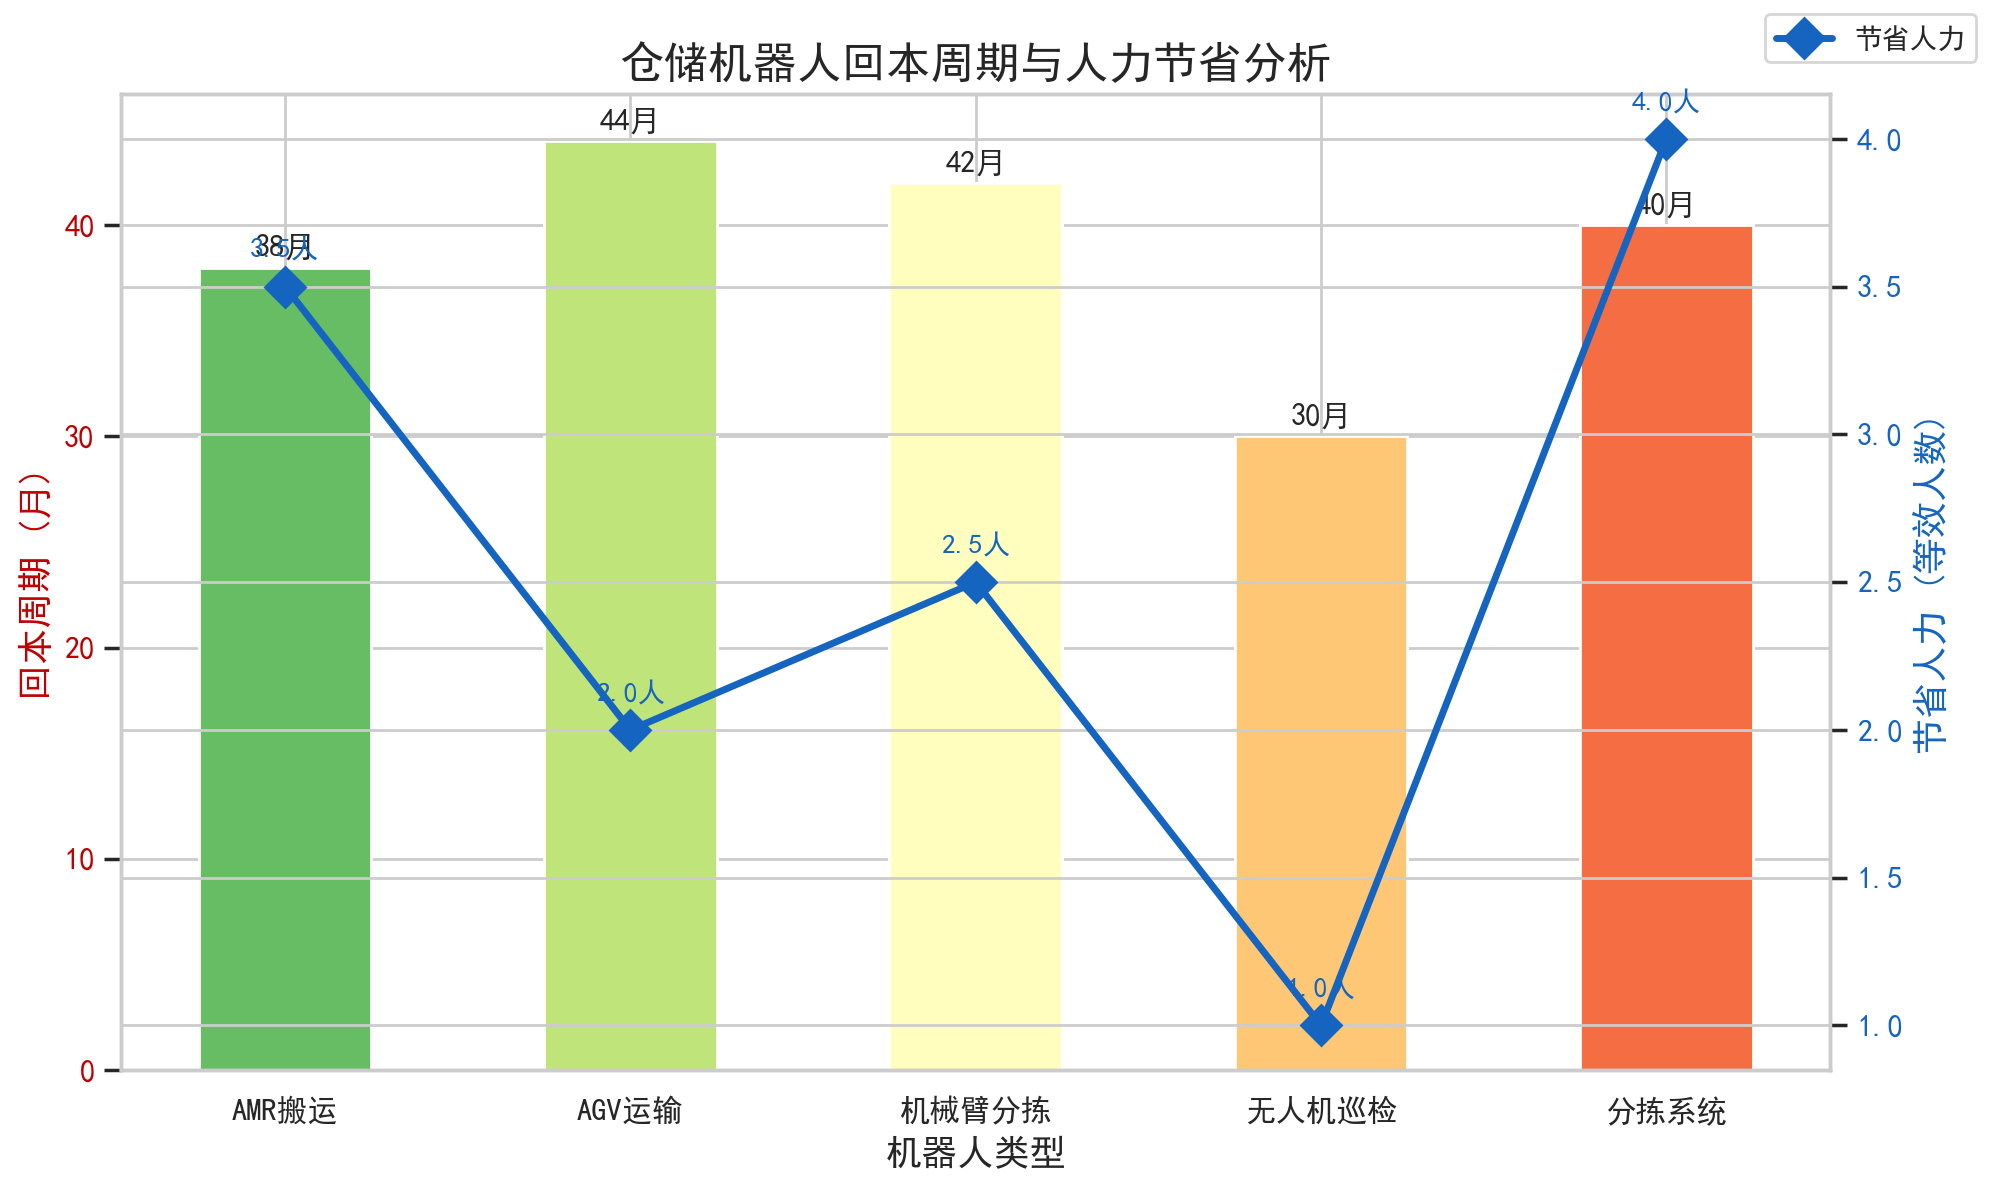

图9已保存: 09_payback_dualaxis.png


In [14]:
# ============================================================
# 图9: 回本周期与节省人力 - 双变量图
# 技术参考: 柱状图 - 双Y轴
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=200)

colors_roi = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(roi_categories)))
bars = ax1.bar(roi_categories, payback_months, color=colors_roi,
               edgecolor='white', width=0.5)
ax1.set_xlabel('机器人类型', fontsize=13)
ax1.set_ylabel('回本周期 (月)', fontsize=13, color='#C00000')
ax1.tick_params(axis='y', labelcolor='#C00000')

for bar, v in zip(bars, payback_months):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v}月', ha='center', fontsize=11, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(roi_categories, labor_saved, 'D-', color='#1565C0',
         linewidth=2.5, markersize=10, label='节省人力')
ax2.set_ylabel('节省人力 (等效人数)', fontsize=13, color='#1565C0')
ax2.tick_params(axis='y', labelcolor='#1565C0')

for i, (x, y) in enumerate(zip(roi_categories, labor_saved)):
    ax2.annotate(f'{y}人', (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10,
                fontweight='bold', color='#1565C0')

ax1.set_title('仓储机器人回本周期与人力节省分析', fontsize=16, fontweight='bold')
fig.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/figures/09_payback_dualaxis.png', dpi=200, bbox_inches='tight')
plt.show()
print("图9已保存: 09_payback_dualaxis.png")


## 7. 电商机器人应用场景分析

In [15]:
# ============================================================
# 5. 应用场景数据
# ============================================================
scenarios = ['订单拣选', '包裹分拣', '库存管理', '搬运运输', '包装码垛', '最后一公里配送']
scenario_pct_2023 = [32, 28, 18, 12, 7, 3]
scenario_pct_2025 = [35, 25, 15, 10, 9, 6]
scenario_efficiency = [85, 92, 70, 65, 78, 55]
scenario_accuracy = [99.2, 99.8, 95.0, 90.0, 97.5, 85.0]

df_scenario = pd.DataFrame({
    '应用场景': scenarios,
    '2023占比(%)': scenario_pct_2023,
    '2025占比(%)': scenario_pct_2025,
    '效率提升(%)': scenario_efficiency,
    '准确率(%)': scenario_accuracy
})
df_scenario


,应用场景,2023占比(%),2025占比(%),效率提升(%),准确率(%)
0,订单拣选,32,35,85,99.2
1,包裹分拣,28,25,92,99.8
2,库存管理,18,15,70,95.0
3,搬运运输,12,10,65,90.0
4,包装码垛,7,9,78,97.5
5,最后一公里配送,3,6,55,85.0


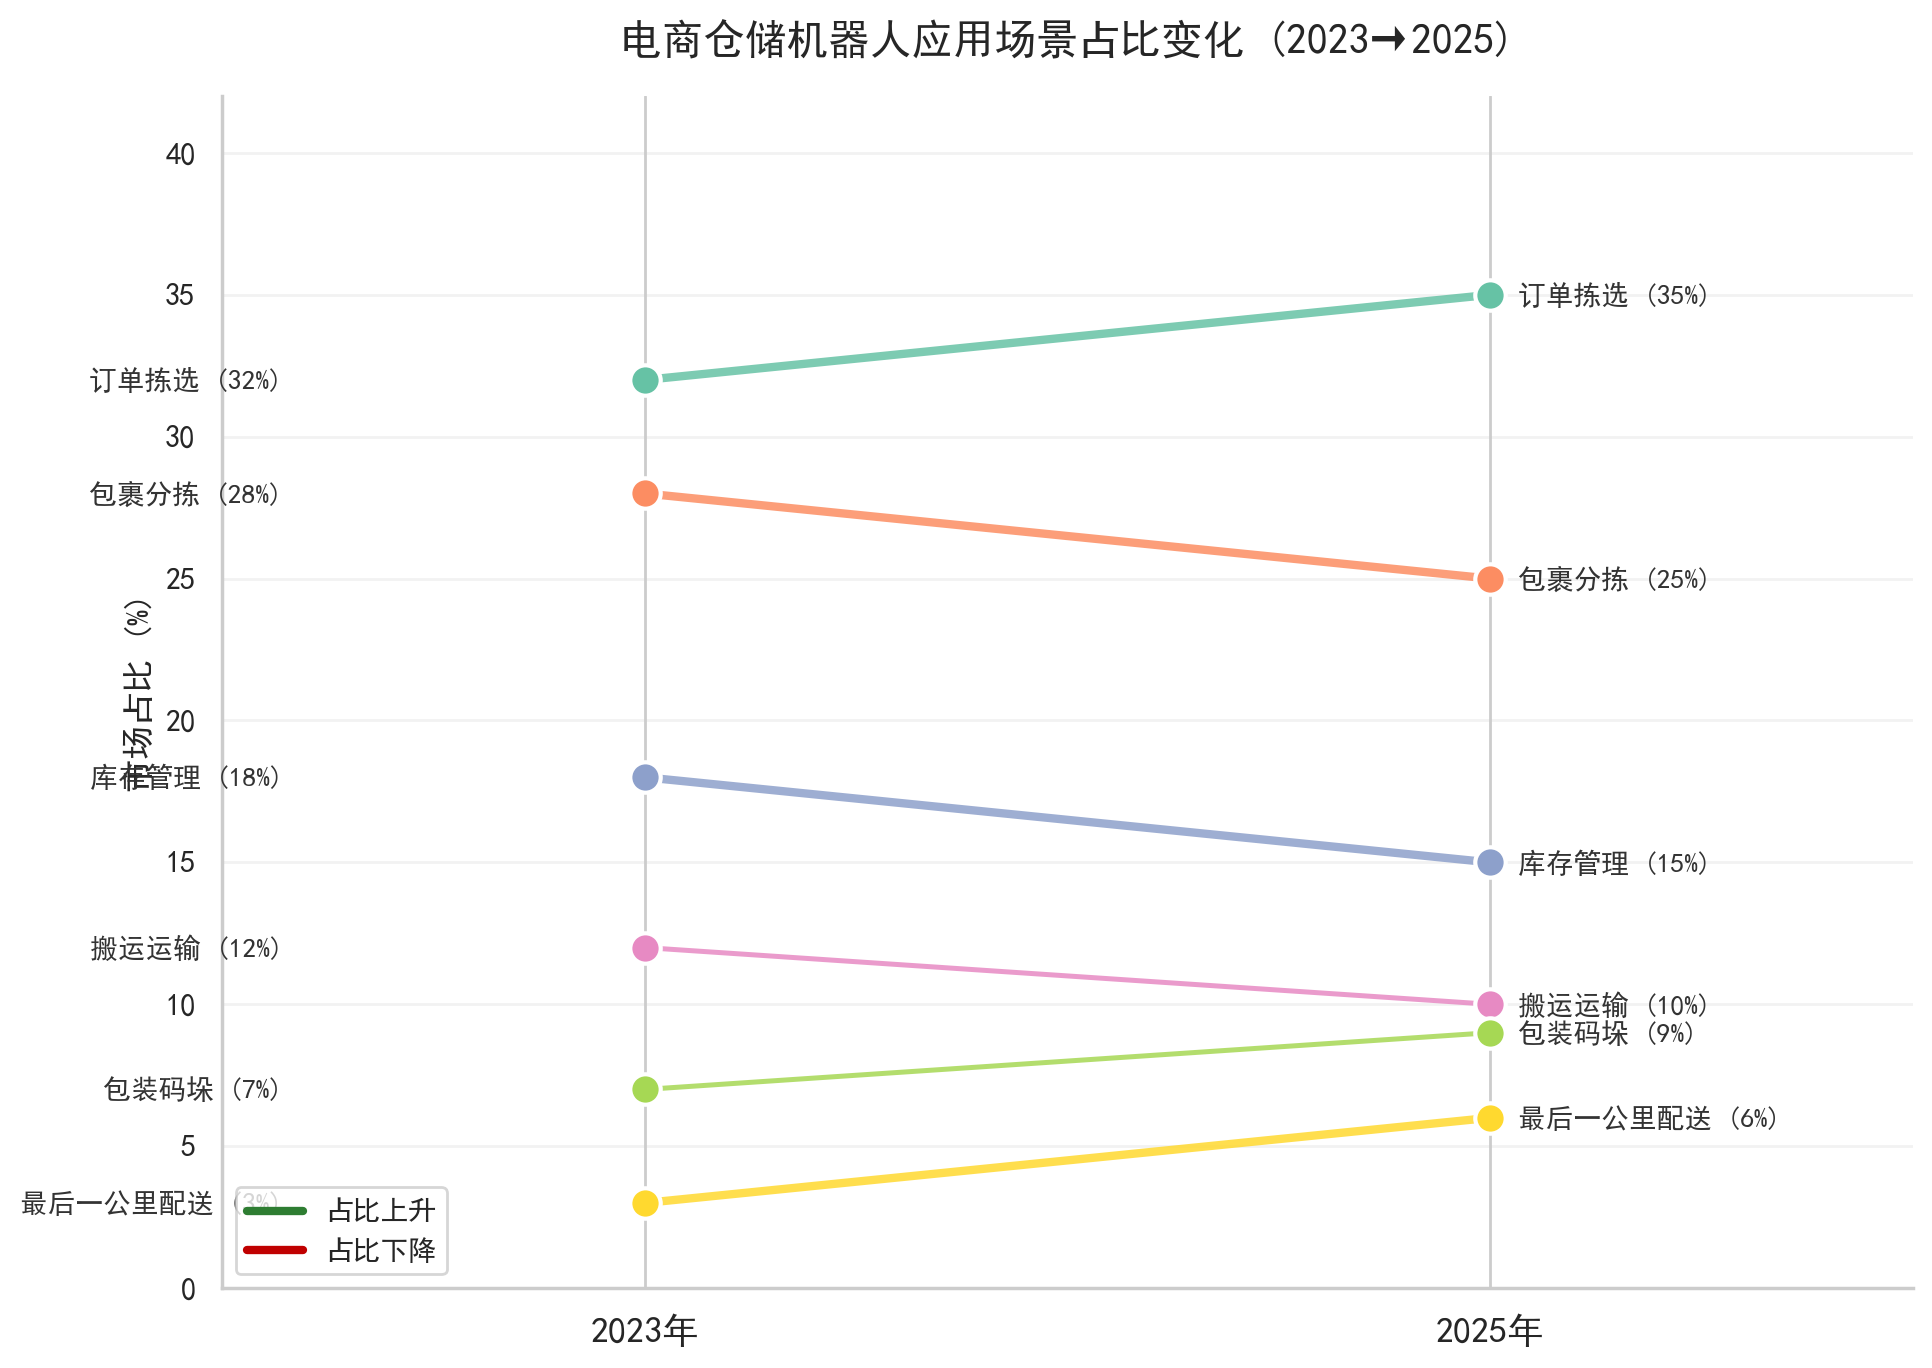

图10已保存: 10_scenario_pie_compare.png (斜率图)


In [16]:
# ============================================================
# 图10: 应用场景占比变化 - 斜率图 (Slope Chart)
# 技术参考: 斜率图 — 两列标签 + 连接线，直观展示变化方向
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)

# 为每个场景分配颜色
slope_colors = sns.color_palette('Set2', len(scenarios))

for i, (scene, p23, p25) in enumerate(zip(scenarios, scenario_pct_2023, scenario_pct_2025)):
    direction = 'increase' if p25 >= p23 else 'decrease'
    color = slope_colors[i]
    # 连接线
    ax.plot([0, 1], [p23, p25], '-', color=color, linewidth=3 if abs(p25-p23) > 2 else 1.8,
            alpha=0.85, zorder=2)
    # 数据点
    ax.scatter([0, 1], [p23, p25], s=120, color=color, edgecolors='white',
               linewidth=1.5, zorder=3)
    # 标签
    ax.annotate(f'{scene} ({p23}%)', (0, p23), textcoords="offset points",
                xytext=(-130, 0), ha='right', va='center', fontsize=10, color='#333')
    ax.annotate(f'{scene} ({p25}%)', (1, p25), textcoords="offset points",
                xytext=(10, 0), ha='left', va='center', fontsize=10, color='#333',
                fontweight='bold' if abs(p25-p23) > 2 else 'normal')

# 装饰
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 42)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2023年', '2025年'], fontsize=13, fontweight='bold')
ax.set_ylabel('市场占比 (%)', fontsize=12)
ax.set_title('电商仓储机器人应用场景占比变化 (2023→2025)', fontsize=15, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25)

# 图例：标注上升/下降
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2E7D32', linewidth=3, label='占比上升'),
    Line2D([0], [0], color='#C00000', linewidth=3, label='占比下降'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/10_scenario_pie_compare.png', dpi=200, bbox_inches='tight')
plt.show()
print("图10已保存: 10_scenario_pie_compare.png (斜率图)")

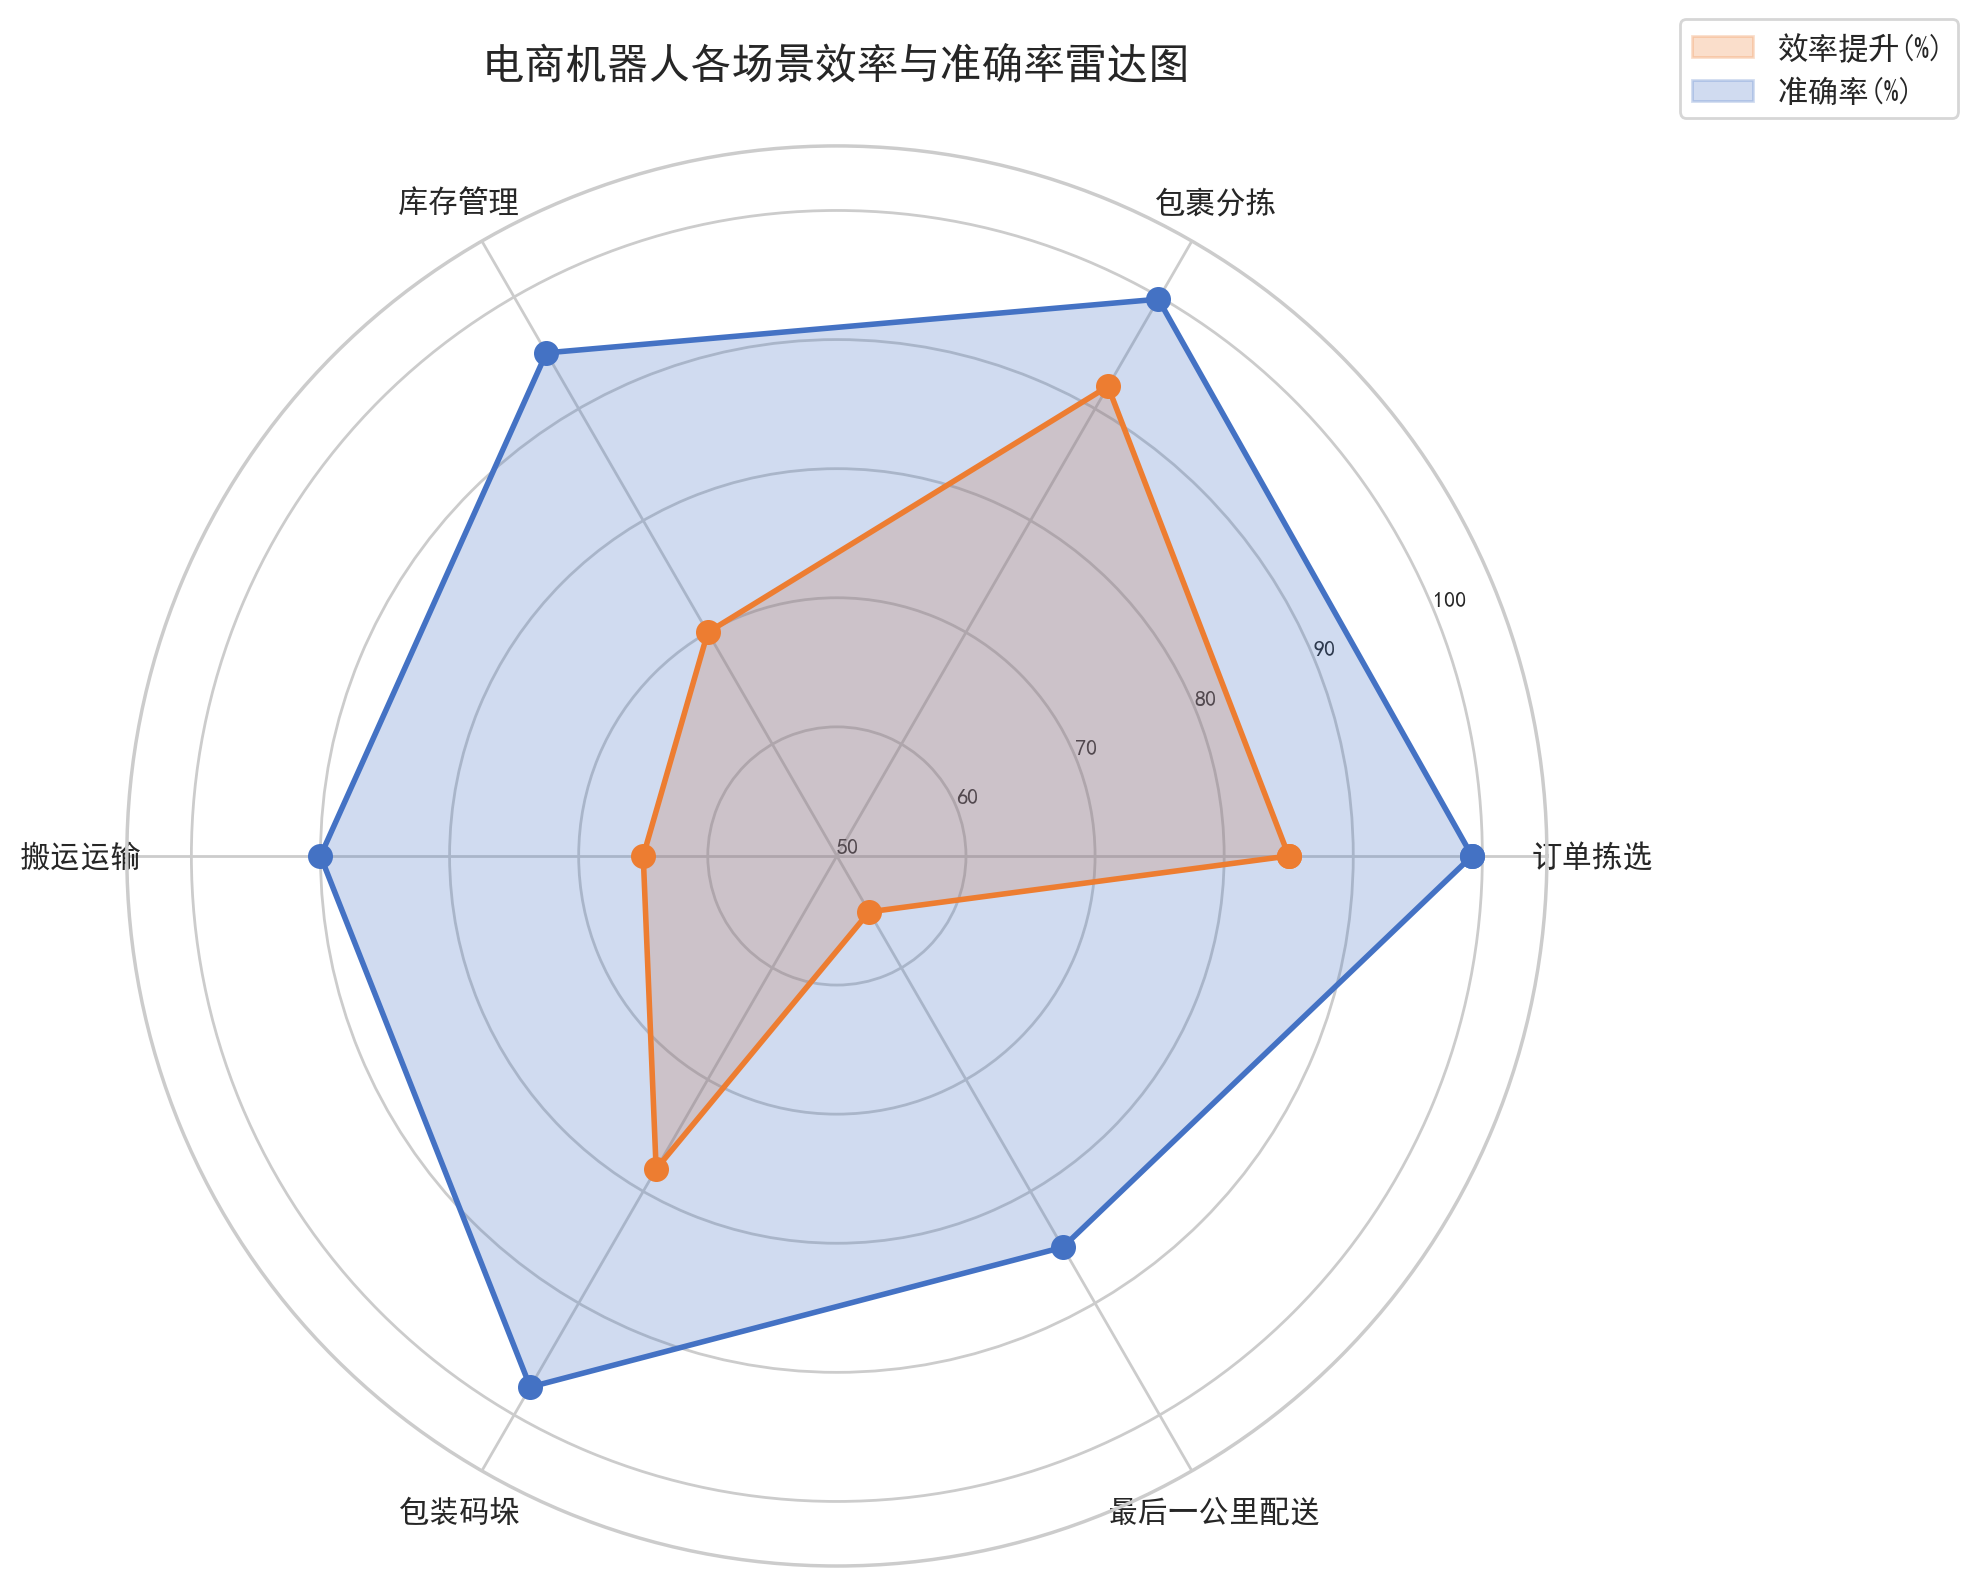

图11已保存: 11_scenario_radar.png


In [17]:
# ============================================================
# 图11: 应用场景效率与准确率 - 雷达图
# 技术参考: 多子图 - polar投影
# 修复: ylim 从 (0,105) 缩小到 (50,105) 放大差异
# ============================================================
fig, ax = plt.subplots(figsize=(10, 8), dpi=200, subplot_kw=dict(polar=True))

n_categories = len(scenarios)
angles = np.linspace(0, 2*np.pi, n_categories, endpoint=False).tolist()
angles += angles[:1]

eff_norm = scenario_efficiency + scenario_efficiency[:1]
acc_norm = scenario_accuracy + scenario_accuracy[:1]

ax.fill(angles, eff_norm, alpha=0.25, color='#ED7D31', label='效率提升(%)')
ax.plot(angles, eff_norm, 'o-', color='#ED7D31', linewidth=2, markersize=8)
ax.fill(angles, acc_norm, alpha=0.25, color='#4472C4', label='准确率(%)')
ax.plot(angles, acc_norm, 'o-', color='#4472C4', linewidth=2, markersize=8)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylim(50, 105)
ax.set_yticks([50, 60, 70, 80, 90, 100])
ax.set_yticklabels(['50', '60', '70', '80', '90', '100'], fontsize=8)
ax.set_title('电商机器人各场景效率与准确率雷达图', fontsize=15, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig('outputs/figures/11_scenario_radar.png', dpi=200, bbox_inches='tight')
plt.show()
print("图11已保存: 11_scenario_radar.png")

## 8. 综合分析面板 - GridSpec多子图

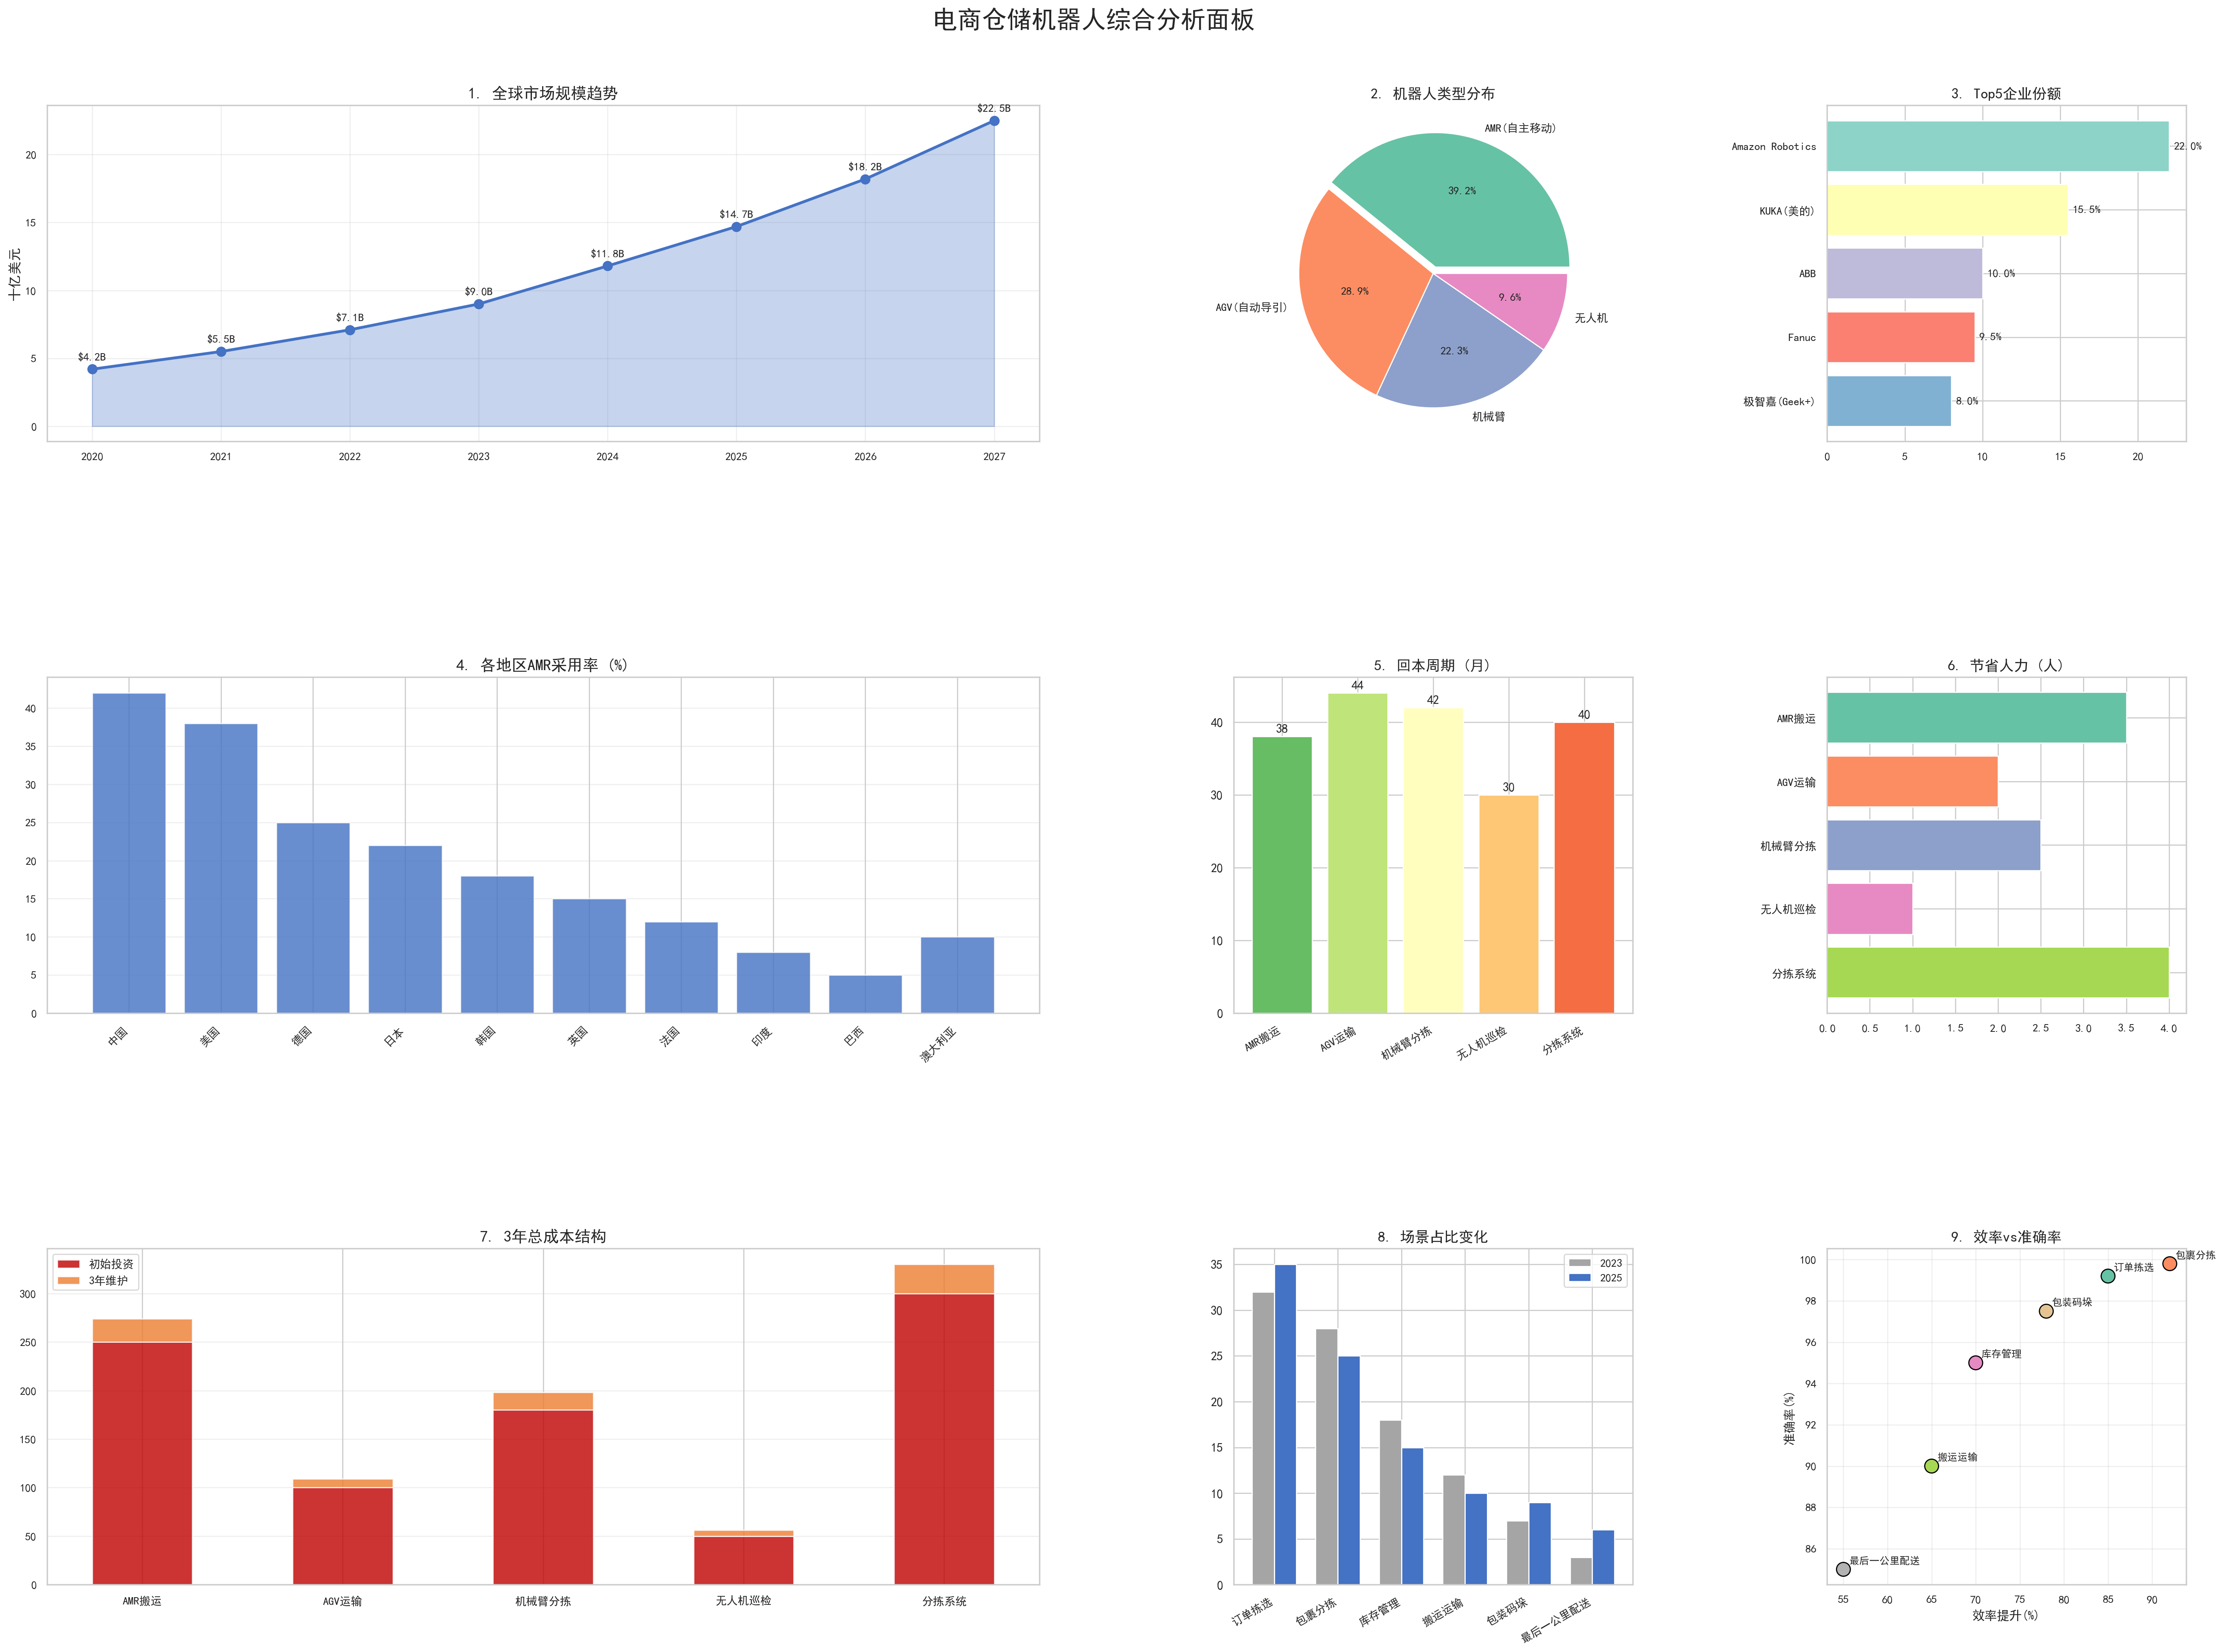

图14已保存: 14_dashboard_gridspec.png


In [18]:
# ============================================================
# 图14: 综合分析面板 - matplotlib.gridspec
# 技术参考: 多子图/8-子图 - GridSpec
# 布局: 28x20大画布 + 充足间距 + 保持正常字号
# ============================================================
fig = plt.figure(figsize=(28, 20), dpi=200)
gs = matplotlib.gridspec.GridSpec(3, 4, figure=fig,
                                   width_ratios=[1, 1, 1, 0.9],
                                   height_ratios=[1, 1, 1])

# (0,0:2) - 市场趋势
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(years, market_size, alpha=0.3, color='#4472C4')
ax1.plot(years, market_size, 'o-', color='#4472C4', linewidth=2.5, markersize=8)
for x, y in zip(years, market_size):
    ax1.annotate(f'${y}B', (x, y), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=10)
ax1.set_title('1. 全球市场规模趋势', fontsize=14, fontweight='bold')
ax1.set_ylabel('十亿美元', fontsize=12)
ax1.tick_params(labelsize=10)
ax1.grid(alpha=0.3)

# (0,2) - 饼图
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(robot_market_share[:4], labels=robot_types[:4],
        autopct='%.1f%%', colors=sns.color_palette('Set2', 4),
        explode=[0.05, 0, 0, 0], textprops={'fontsize': 10})
ax2.set_title('2. 机器人类型分布', fontsize=13, fontweight='bold')

# (0,3) - Top5企业
ax3 = fig.add_subplot(gs[0, 3])
top5_names = companies[:5]
top5_shares = market_shares[:5]
bars = ax3.barh(top5_names[::-1], top5_shares[::-1],
                color=sns.color_palette('Set3', 5)[::-1])
ax3.set_title('3. Top5企业份额', fontsize=13, fontweight='bold')
ax3.tick_params(labelsize=10)
for bar, v in zip(bars, top5_shares[::-1]):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{v}%', va='center', fontsize=10)

# (1,0:2) - 各地区AMR
ax4 = fig.add_subplot(gs[1, :2])
ax4.bar(regions, amr_adoption, color='#4472C4', alpha=0.8)
ax4.set_xticklabels(regions, rotation=45, ha='right', fontsize=10)
ax4.set_title('4. 各地区AMR采用率 (%)', fontsize=14, fontweight='bold')
ax4.tick_params(labelsize=10)
ax4.grid(axis='y', alpha=0.3)

# (1,2) - 回本周期
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(roi_categories, payback_months,
        color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 5)))
ax5.set_title('5. 回本周期 (月)', fontsize=13, fontweight='bold')
ax5.set_xticklabels(roi_categories, rotation=30, ha='right', fontsize=10)
for i, v in enumerate(payback_months):
    ax5.text(i, v + 0.5, str(v), ha='center', fontsize=11)

# (1,3) - 节省人力
ax6 = fig.add_subplot(gs[1, 3])
ax6.barh(roi_categories[::-1], labor_saved[::-1],
         color=sns.color_palette('Set2', 5)[::-1])
ax6.set_title('6. 节省人力 (人)', fontsize=13, fontweight='bold')
ax6.tick_params(labelsize=10)

# (2,0:2) - ROI堆叠图
ax7 = fig.add_subplot(gs[2, :2])
x_roi = np.arange(len(roi_categories))
ax7.bar(x_roi, initial_cost, width=0.5, label='初始投资', color='#C00000', alpha=0.8)
ax7.bar(x_roi, [m*3 for m in maintenance_cost], width=0.5,
        bottom=initial_cost, label='3年维护', color='#ED7D31', alpha=0.8)
ax7.set_xticks(x_roi)
ax7.set_xticklabels(roi_categories, fontsize=11)
ax7.set_title('7. 3年总成本结构', fontsize=14, fontweight='bold')
ax7.legend(fontsize=10)
ax7.tick_params(labelsize=10)
ax7.grid(axis='y', alpha=0.3)

# (2,2) - 场景变化
ax8 = fig.add_subplot(gs[2, 2])
x_sc = np.arange(len(scenarios))
width_sc = 0.35
ax8.bar(x_sc - width_sc/2, scenario_pct_2023, width_sc, label='2023', color='#A5A5A5')
ax8.bar(x_sc + width_sc/2, scenario_pct_2025, width_sc, label='2025', color='#4472C4')
ax8.set_xticks(x_sc)
ax8.set_xticklabels(scenarios, rotation=30, ha='right', fontsize=10)
ax8.set_title('8. 场景占比变化', fontsize=13, fontweight='bold')
ax8.legend(fontsize=10)

# (2,3) - 效率vs准确率
ax9 = fig.add_subplot(gs[2, 3])
ax9.scatter(scenario_efficiency, scenario_accuracy, s=150,
            c=range(len(scenarios)), cmap='Set2', edgecolors='black')
for i, s in enumerate(scenarios):
    ax9.annotate(s, (scenario_efficiency[i], scenario_accuracy[i]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax9.set_xlabel('效率提升(%)', fontsize=11)
ax9.set_ylabel('准确率(%)', fontsize=11)
ax9.set_title('9. 效率vs准确率', fontsize=13, fontweight='bold')
ax9.tick_params(labelsize=10)
ax9.grid(alpha=0.3)

fig.suptitle('电商仓储机器人综合分析面板', fontsize=22, fontweight='bold', y=1.01)
plt.subplots_adjust(wspace=0.5, hspace=0.7, left=0.04, right=0.98, top=0.95, bottom=0.04)
plt.savefig('outputs/figures/14_dashboard_gridspec.png', dpi=200, bbox_inches='tight')
plt.show()
print("图14已保存: 14_dashboard_gridspec.png")

## 9. 未来趋势预测

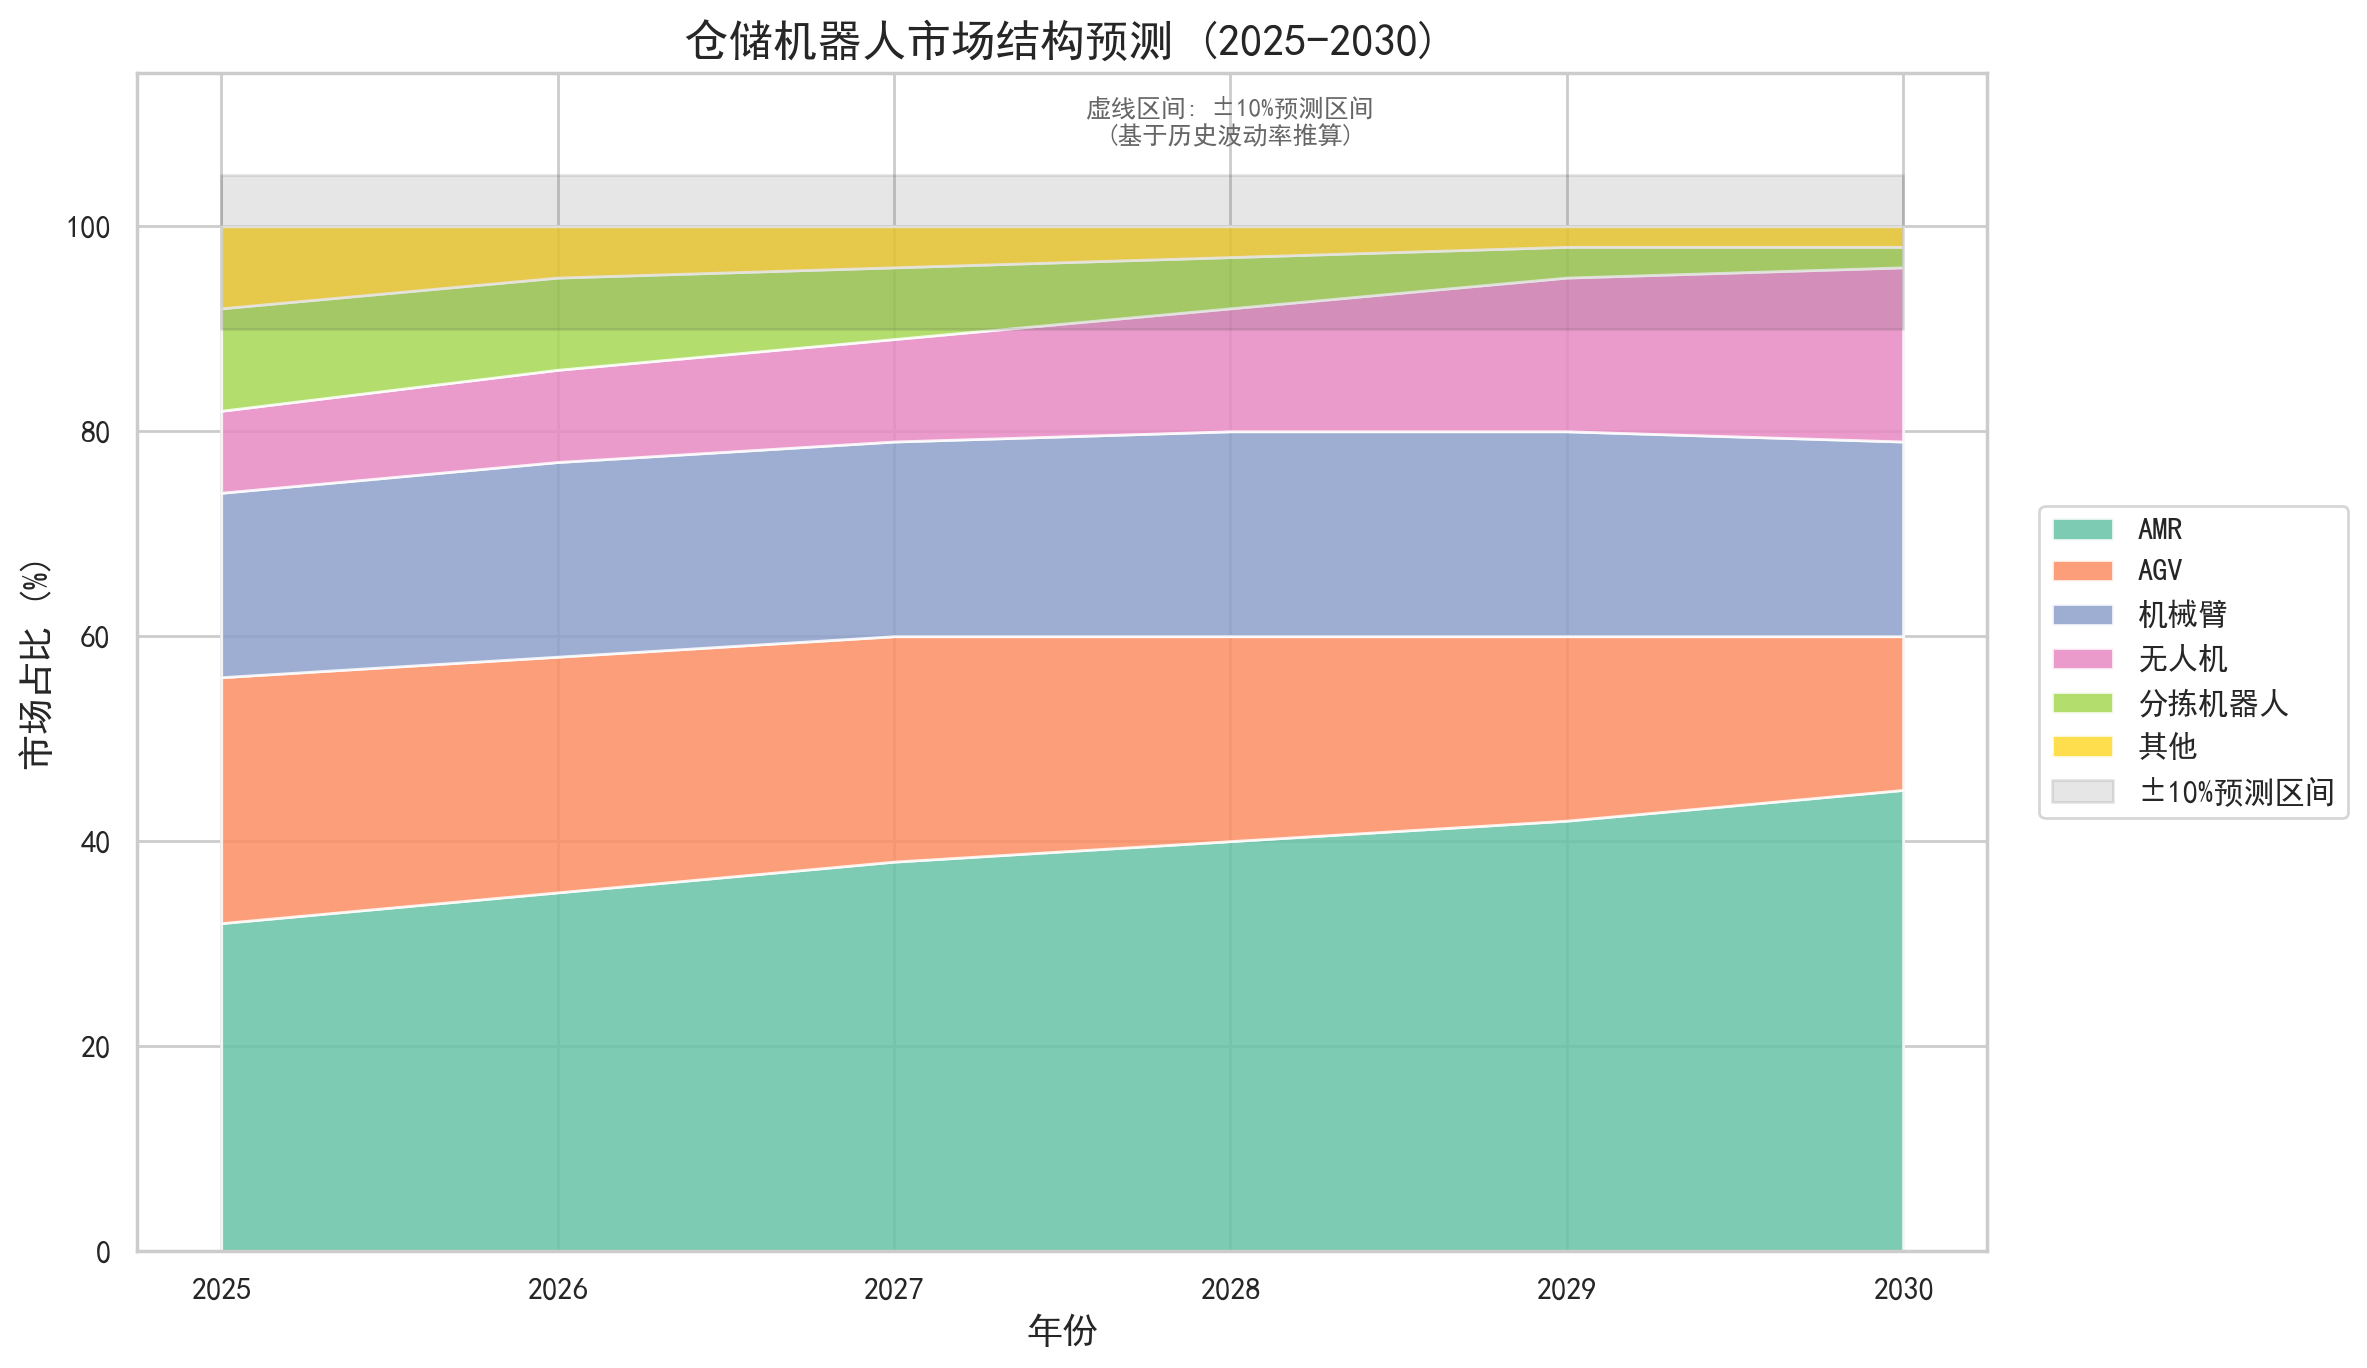

图12已保存: 12_future_stacked_area.png


In [19]:
# ============================================================
# 图12: 未来趋势 - 堆叠面积图 + 预测置信区间
# 技术参考: 饼图与堆叠面积图 - plt.stackplot
# ============================================================
future_years = [2025, 2026, 2027, 2028, 2029, 2030]
amr_share =    [32, 35, 38, 40, 42, 45]
agv_share =    [24, 23, 22, 20, 18, 15]
arm_share =    [18, 19, 19, 20, 20, 19]
drone_share =  [8,  9,  10, 12, 15, 17]
sorting_share =[10, 9,  7,  5,  3,  2]
other_share =  [8,  5,  4,  3,  2,  2]

fig, ax = plt.subplots(figsize=(12, 7), dpi=200)

ax.stackplot(future_years,
             amr_share, agv_share, arm_share,
             drone_share, sorting_share, other_share,
             labels=['AMR', 'AGV', '机械臂', '无人机', '分拣机器人', '其他'],
             colors=sns.color_palette('Set2', 6), alpha=0.85)

# 添加总市场规模预测线 + 置信区间
total_share = np.array(amr_share) + np.array(agv_share) + np.array(arm_share) + \
              np.array(drone_share) + np.array(sorting_share) + np.array(other_share)
# 基于历史波动率推算 ±10% 预测区间
ax.fill_between(future_years, total_share * 0.9, total_share * 1.05,
                alpha=0.12, color='#333', label='±10%预测区间')
ax.annotate('虚线区间: ±10%预测区间\n(基于历史波动率推算)',
            xy=(2028, 108), fontsize=9, color='#666',
            ha='center', style='italic')

ax.set_xlabel('年份', fontsize=13)
ax.set_ylabel('市场占比 (%)', fontsize=13)
ax.set_title('仓储机器人市场结构预测 (2025-2030)', fontsize=16, fontweight='bold')
ax.set_xticks(future_years)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.savefig('outputs/figures/12_future_stacked_area.png', dpi=200, bbox_inches='tight')
plt.show()
print("图12已保存: 12_future_stacked_area.png")

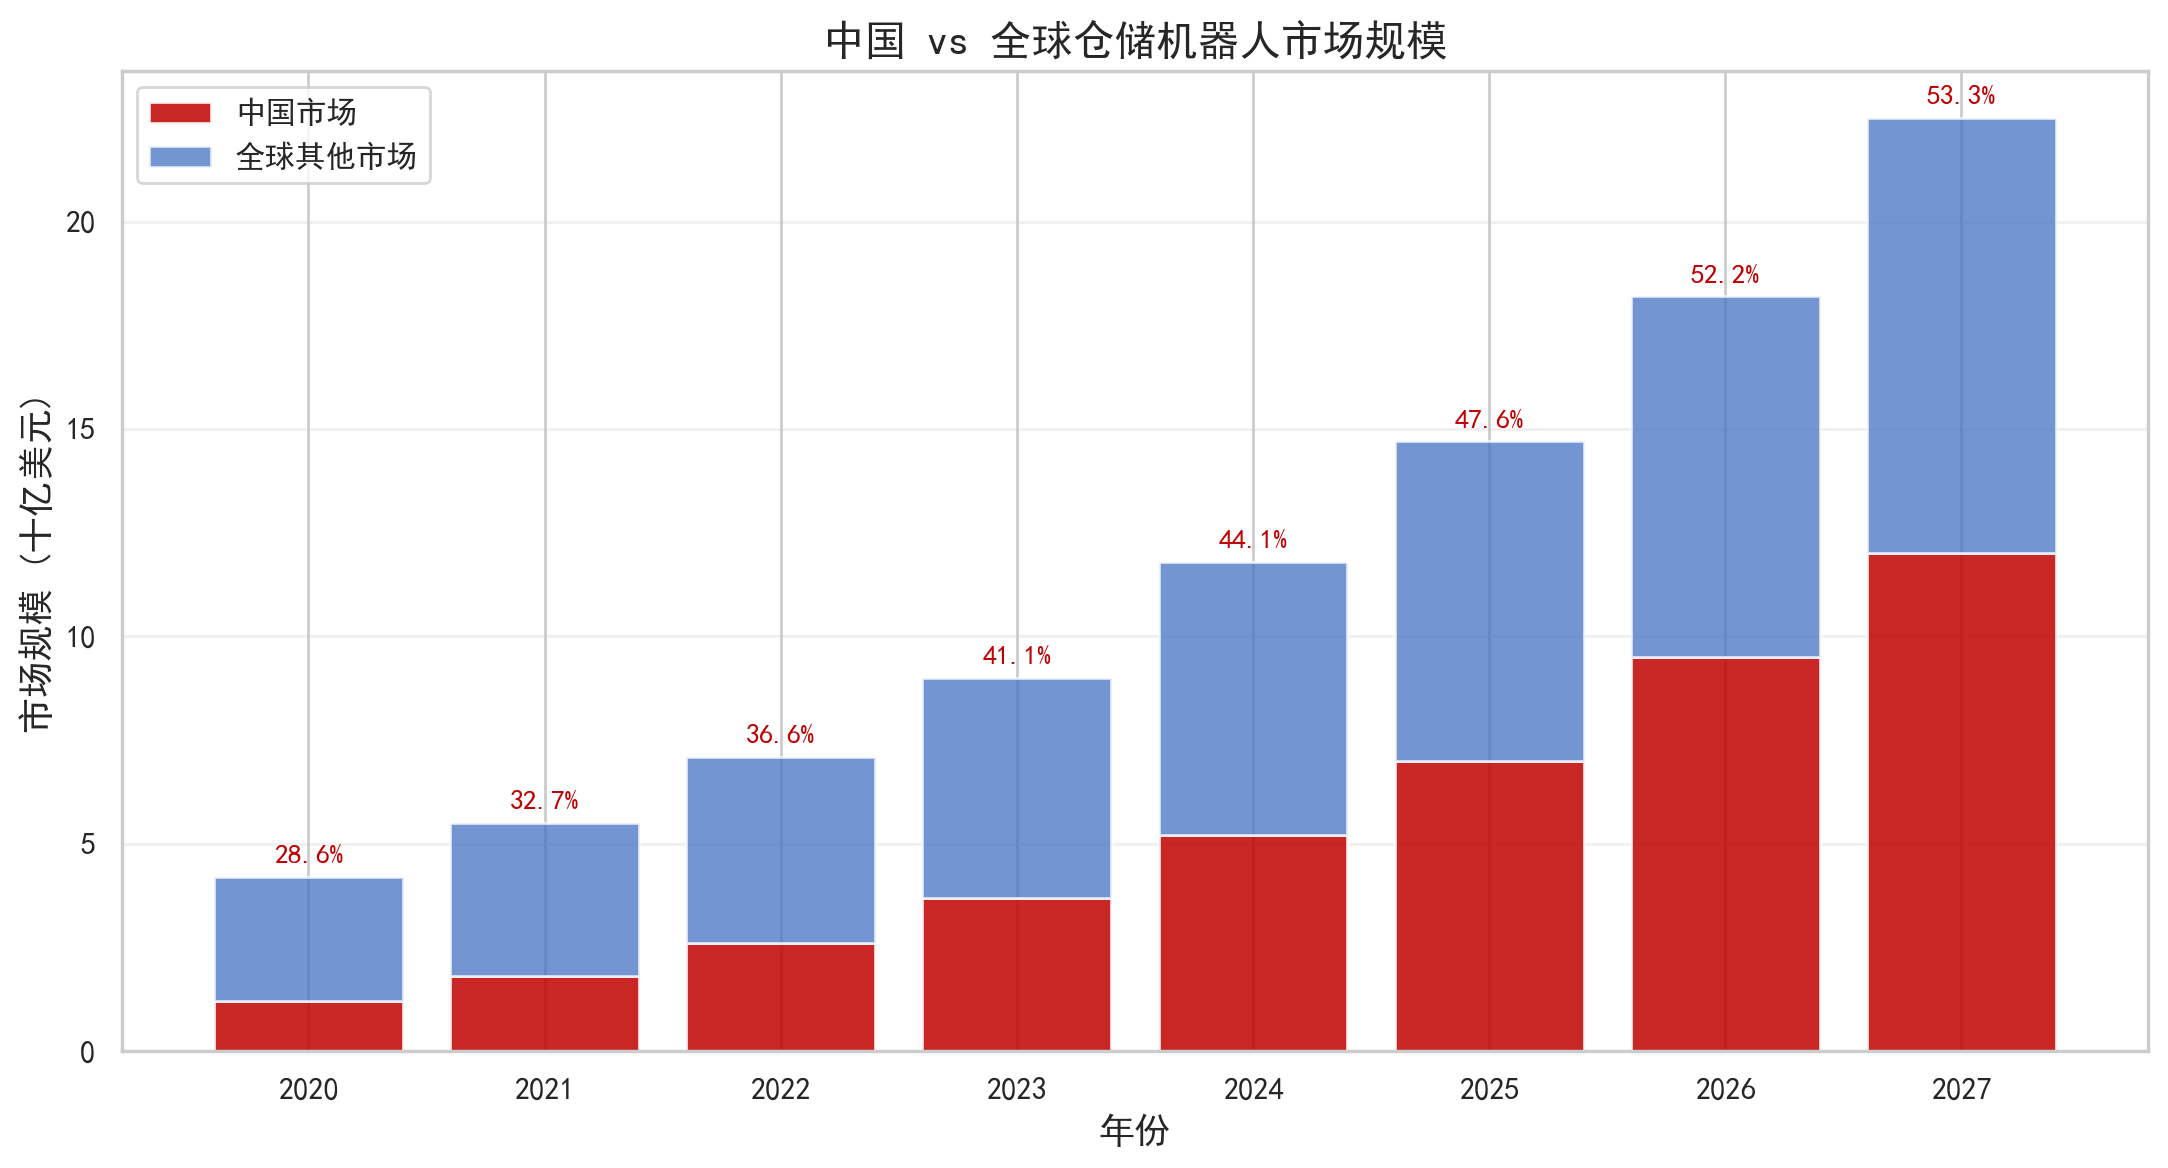

图13已保存: 13_china_vs_global.png


In [20]:
# ============================================================
# 图13: 中国 vs 全球市场
# 技术参考: 柱状图/5-堆叠柱状图
# ============================================================
china_market = [1.2, 1.8, 2.6, 3.7, 5.2, 7.0, 9.5, 12.0]
global_ex_china = [m - c for m, c in zip(market_size, china_market)]

fig, ax = plt.subplots(figsize=(11, 6), dpi=200)

ax.bar(years, china_market, label='中国市场', color='#C00000', alpha=0.85)
ax.bar(years, global_ex_china, bottom=china_market,
       label='全球其他市场', color='#4472C4', alpha=0.75)

for i, (y, c, g) in enumerate(zip(years, china_market, global_ex_china)):
    pct = c / (c + g) * 100
    ax.text(y, c + g + 0.3, f'{pct:.1f}%', ha='center',
            fontsize=10, fontweight='bold', color='#C00000')

ax.set_xlabel('年份', fontsize=13)
ax.set_ylabel('市场规模 (十亿美元)', fontsize=13)
ax.set_title('中国 vs 全球仓储机器人市场规模', fontsize=15, fontweight='bold')
ax.set_xticks(years)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/13_china_vs_global.png', dpi=200, bbox_inches='tight')
plt.show()
print("图13已保存: 13_china_vs_global.png")

## 10. 小结与关键发现

1. **市场高速增长**：全球仓储机器人市场从2020年$4.2B增长至2027年预计$22.5B，CAGR超过25%
2. **中国引领市场**：中国占全球市场份额超50%，且增速快于全球平均水平
3. **AMR成主流**：自主移动机器人(AMR)以32.5%份额成为最主流类型
4. **ROI可观**：大多数仓储机器人3年内可收回投资，同时节省2-4名人力
5. **无人机快速增长**：无人机巡检年增长率最高(42.5%)，是下一个爆发点
6. **竞争激烈**：Amazon Robotics领先，中国极智嘉、海柔创新快速追赶


In [21]:
print("=" * 60)
print("电商仓储机器人分析完成!")
print("所有图表已保存至 outputs/figures/ 目录")
print("共生成 14 张图表:")
print("=" * 60)
import os
for f in sorted(os.listdir('outputs/figures')):
    if f.endswith('.png'):
        print(f"  {f}")
print("=" * 60)
print("可直接将 outputs/figures/ 中的图片插入PPT报告")


电商仓储机器人分析完成!
所有图表已保存至 outputs/figures/ 目录
共生成 14 张图表:
  01_market_size_trend.png
  02_robot_market_pie.png
  03_robot_growth_barh.png
  04_regional_adoption_bar.png
  05_investment_heatmap.png
  06_company_treemap.png
  07_company_bubble.png
  08_roi_stacked_bar.png
  09_payback_dualaxis.png
  10_scenario_pie_compare.png
  11_scenario_radar.png
  12_dashboard_gridspec.png
  12_future_stacked_area.png
  13_china_vs_global.png
  13_future_stacked_area.png
  14_china_vs_global.png
  14_dashboard_gridspec.png
可直接将 outputs/figures/ 中的图片插入PPT报告
